In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.linear_model import LinearRegression
from statsmodels.tsa import stattools
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from sklearn.model_selection import train_test_split

from statsmodels.tsa.stattools import adfuller

In [ ]:
# Download data harga Bitcoin dari Yahoo Finance
data = yf.download('BTC-USD', start='2015-01-01', end='2025-01-01')
data

/tmp/ipython-input-2-3264187248.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800
...,...,...,...,...,...
2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,52419934565
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185


In [ ]:
# data.to_csv("Bitcoin2015-2024.csv")

# DATA AWAL

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataColab/Bitcoin2015-2024.csv", sep=";")
df

,Date,Close,High,Low,Open,Volume
0,01/01/2015,314.248993,320.434998,314.002991,320.434998,8.036550e+06
1,02/01/2015,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2,03/01/2015,281.082001,315.149994,281.082001,314.846008,3.305440e+07
3,04/01/2015,264.195007,287.230011,257.612000,281.145996,5.562910e+07
4,05/01/2015,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...,...
3648,27/12/2024,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
3649,28/12/2024,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
3650,29/12/2024,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10
3651,30/12/2024,92643.210940,94903.320310,91317.132810,93527.195310,5.618800e+10


In [ ]:
# Mengonversi kolom 'Date' menjadi datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Menjadikan kolom 'Date' sebagai index
df.set_index('Date', inplace=True)

In [ ]:
df

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


# EDA

In [ ]:
df_eda = df.loc["2017-01-01":"2024-12-31"]
df_eda

,Close,High,Low,Open,Volume
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,1.477750e+08
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,2.221850e+08
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,1.851680e+08
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,3.449460e+08
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,5.101990e+08
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


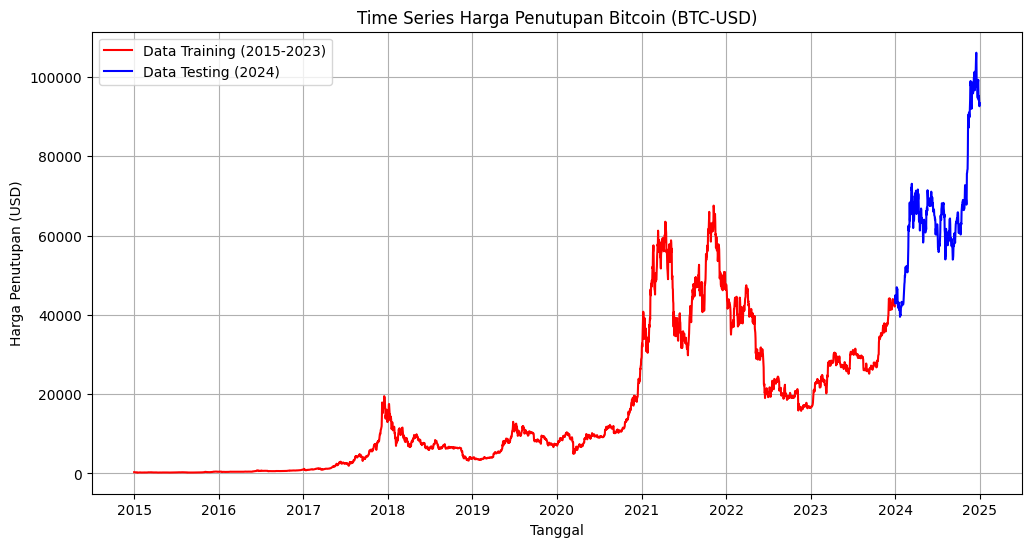

In [ ]:
# prompt: aku ingin membuat plot time series dari data close di df_eda ku tapi aku ingin dari 2015-2023 warna merah sedangkan 2024 warna default biru dan buatlah captionnya merah untuk data training dan biru untuk data testing

# Pisahkan data berdasarkan tahun
df_train = df.loc['2015':'2023']
df_test = df.loc['2024']

# Buat plot time series
plt.figure(figsize=(12, 6))

# Plot data training (2015-2023) berwarna merah
plt.plot(df_train.index, df_train['Close'], color='red', label='Data Training (2015-2023)')

# Plot data testing (2024) berwarna default (biru)
plt.plot(df_test.index, df_test['Close'], color='blue', label='Data Testing (2024)')

# Tambahkan judul dan label sumbu
plt.title('Time Series Harga Penutupan Bitcoin (BTC-USD)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan (USD)')

# Tambahkan legenda
plt.legend()

# Tampilkan plot
plt.grid(True)
plt.show()


## Pergerakan harga Bitcoin dari 2017-2024

<Axes: xlabel='Date'>

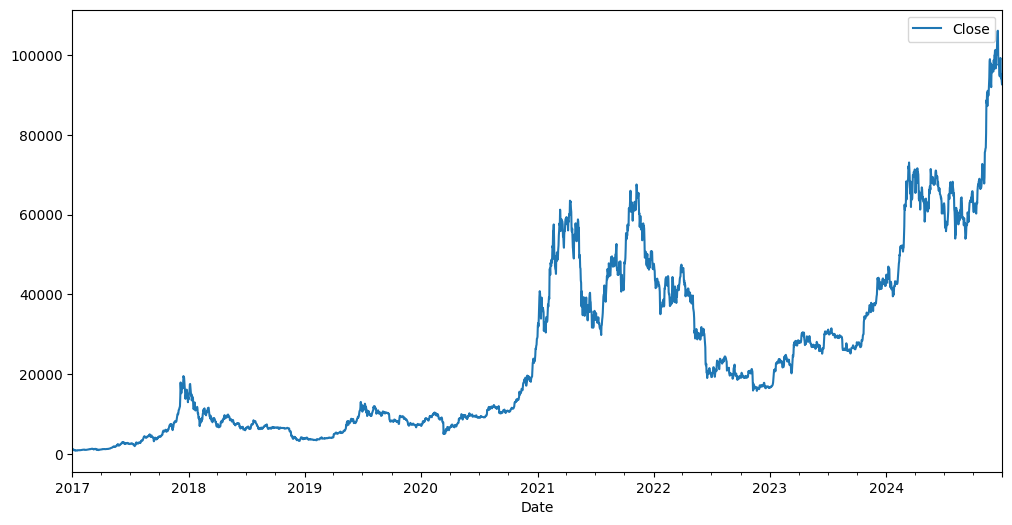

In [ ]:
df_eda.plot(y='Close', figsize=(12,6))

In [ ]:
# fig = go.Figure(data=go.Candlestick(
#     x=df.index,
#     open=df['Open'],
#     high=df['High'],
#     low=df['Low'],
#     close=df['Close'],
#     name='Candlestick'
# ))

# fig.update_layout(
#     template='plotly_dark',
#     title='Grafik Candlestick Harga Bitcoin',
#     xaxis_title='Tanggal',
#     yaxis_title='Harga BTC (USD)',
#     title_x=0.5,
#     xaxis_rangeslider_visible=False
# )

# fig.show()


## **1. Volatilitas harga harian Bitcoin**

/tmp/ipython-input-10-3631986823.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['Volatility'] = df_eda['High'] - df_eda['Low']
/tmp/ipython-input-10-3631986823.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['HighVolatility'] = df_eda['Volatility'] > (mean_vol + 2 * std_vol)


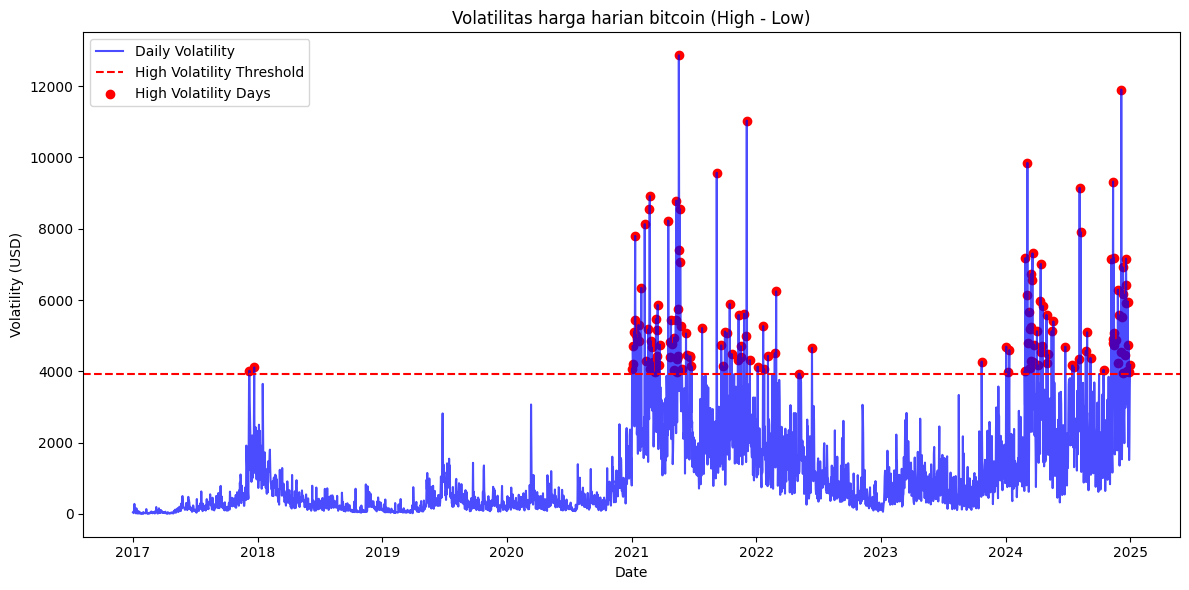

In [ ]:
# Hitung volatilitas harian sebagai selisih High dan Low
df_eda['Volatility'] = df_eda['High'] - df_eda['Low']

# Hitung rata-rata dan standar deviasi volatilitas
mean_vol = df_eda['Volatility'].mean()
std_vol = df_eda['Volatility'].std()

# Tandai hari-hari dengan volatilitas tinggi (misalnya > mean + 2*std)
df_eda['HighVolatility'] = df_eda['Volatility'] > (mean_vol + 2 * std_vol)

# Plot volatilitas harian
plt.figure(figsize=(12, 6))
plt.plot(df_eda.index, df_eda['Volatility'], label='Daily Volatility', color='blue', alpha=0.7)
plt.axhline(mean_vol + 2 * std_vol, color='red', linestyle='--', label='High Volatility Threshold')

# Highlight titik-titik volatilitas tinggi
plt.scatter(df_eda[df_eda['HighVolatility']].index, df_eda[df_eda['HighVolatility']]['Volatility'],
            color='red', label='High Volatility Days')

plt.title('Volatilitas harga harian bitcoin (High - Low)')
plt.xlabel('Date')
plt.ylabel('Volatility (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## **2. Distribusi volatilitas harga Bitcoin tiap tahun dan bulan**

/tmp/ipython-input-11-1562140496.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Volatility', data=df_eda, palette='Set2')


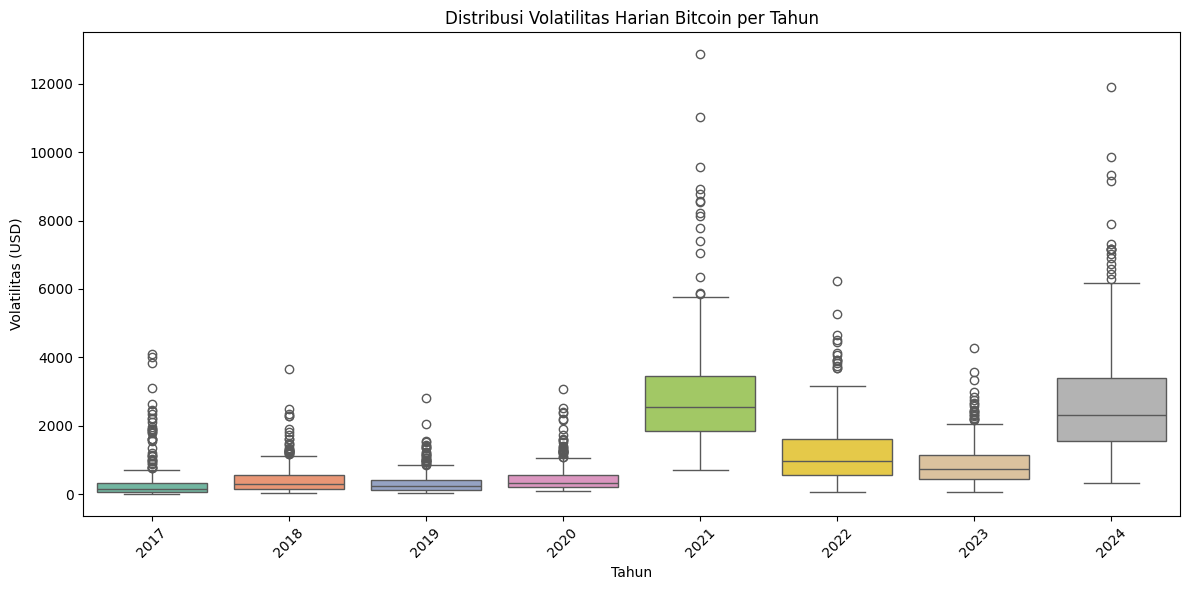

In [ ]:
df_eda = df_eda.reset_index()

# Pastikan kolom 'Date' sudah dalam format datetime dan menjadi index
df_eda['Date'] = pd.to_datetime(df_eda['Date'], dayfirst=True)
df_eda['Year'] = df_eda['Date'].dt.year

# Hitung volatilitas harian (High - Low) jika belum dihitung
if 'Volatility' not in df_eda.columns:
    df_eda['Volatility'] = df_eda['High'] - df_eda['Low']

# Plot boxplot volatilitas per tahun
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Volatility', data=df_eda, palette='Set2')

plt.title('Distribusi Volatilitas Harian Bitcoin per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Volatilitas (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-12-1086843564.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Volatility', data=df_eda,


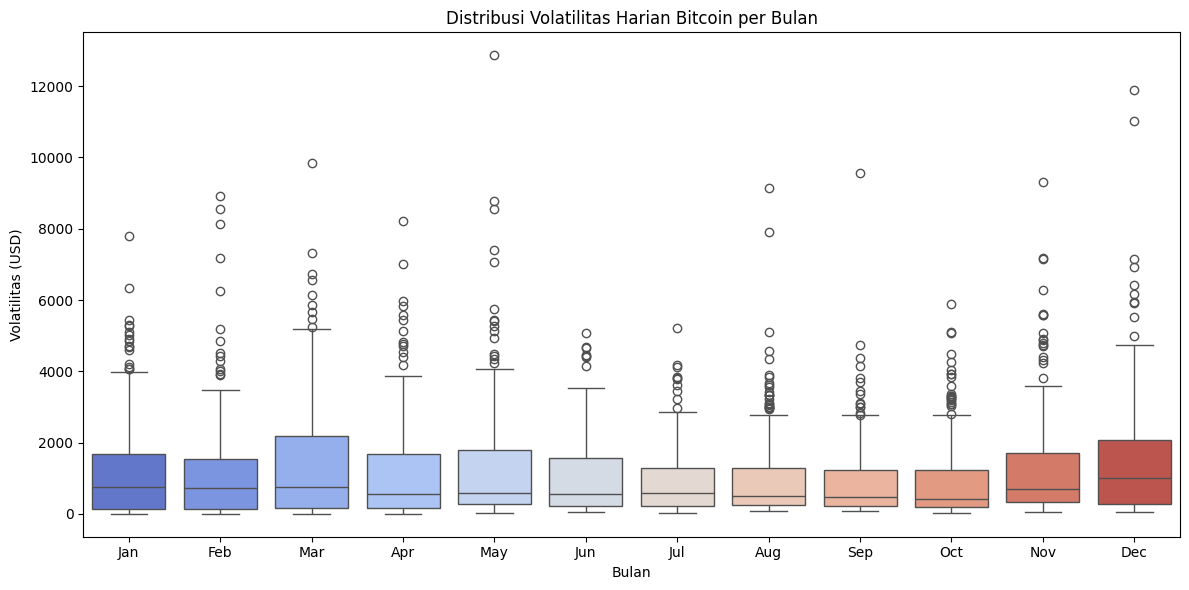

In [ ]:
# df_eda = df_eda.reset_index()

df_eda['Month'] = df_eda['Date'].dt.strftime('%b')  # Nama bulan (Jan, Feb, ...)
df_eda['Month_Num'] = df_eda['Date'].dt.month       # Supaya urut
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Volatility', data=df_eda,
            order=month_order, palette='coolwarm')

plt.title('Distribusi Volatilitas Harian Bitcoin per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Volatilitas (USD)')
plt.tight_layout()
plt.show()


## **3. Hubungan volume perdagangan dengan tingkat volatilitas harga Bitcoin**

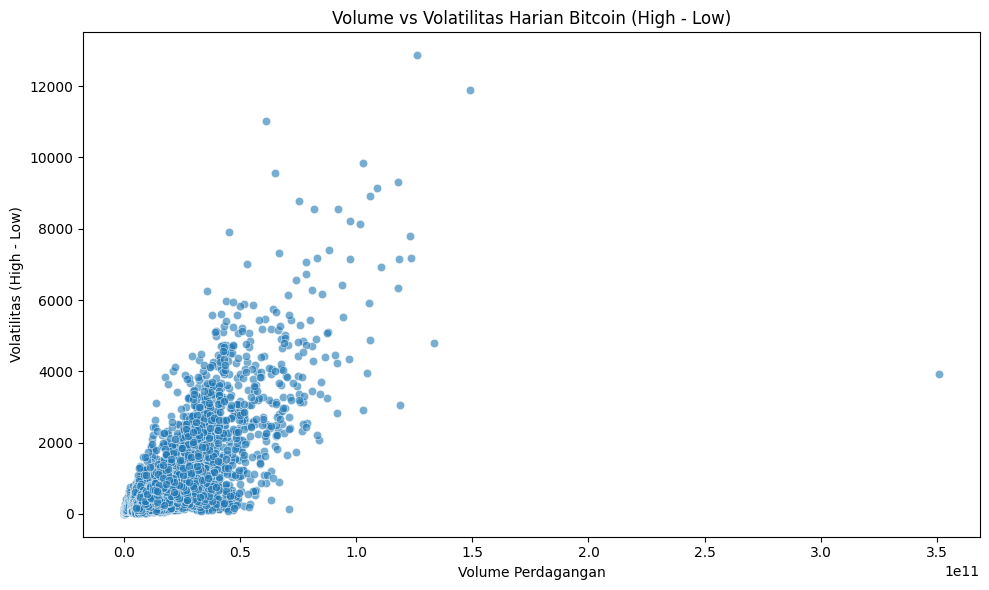

In [ ]:
# Pastikan data sudah bersih
df_eda['Date'] = pd.to_datetime(df_eda['Date'], dayfirst=True)

# Hitung volatilitas jika belum ada
df_eda['Volatility'] = df_eda['High'] - df_eda['Low']

# Plot scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='Volume', y='Volatility', alpha=0.6)

plt.title('Volume vs Volatilitas Harian Bitcoin (High - Low)')
plt.xlabel('Volume Perdagangan')
plt.ylabel('Volatilitas (High - Low)')
plt.tight_layout()
plt.show()


## **4. lonjakan harga atau penurunan drastis yang signifikan dalam pasar Bitcoin**

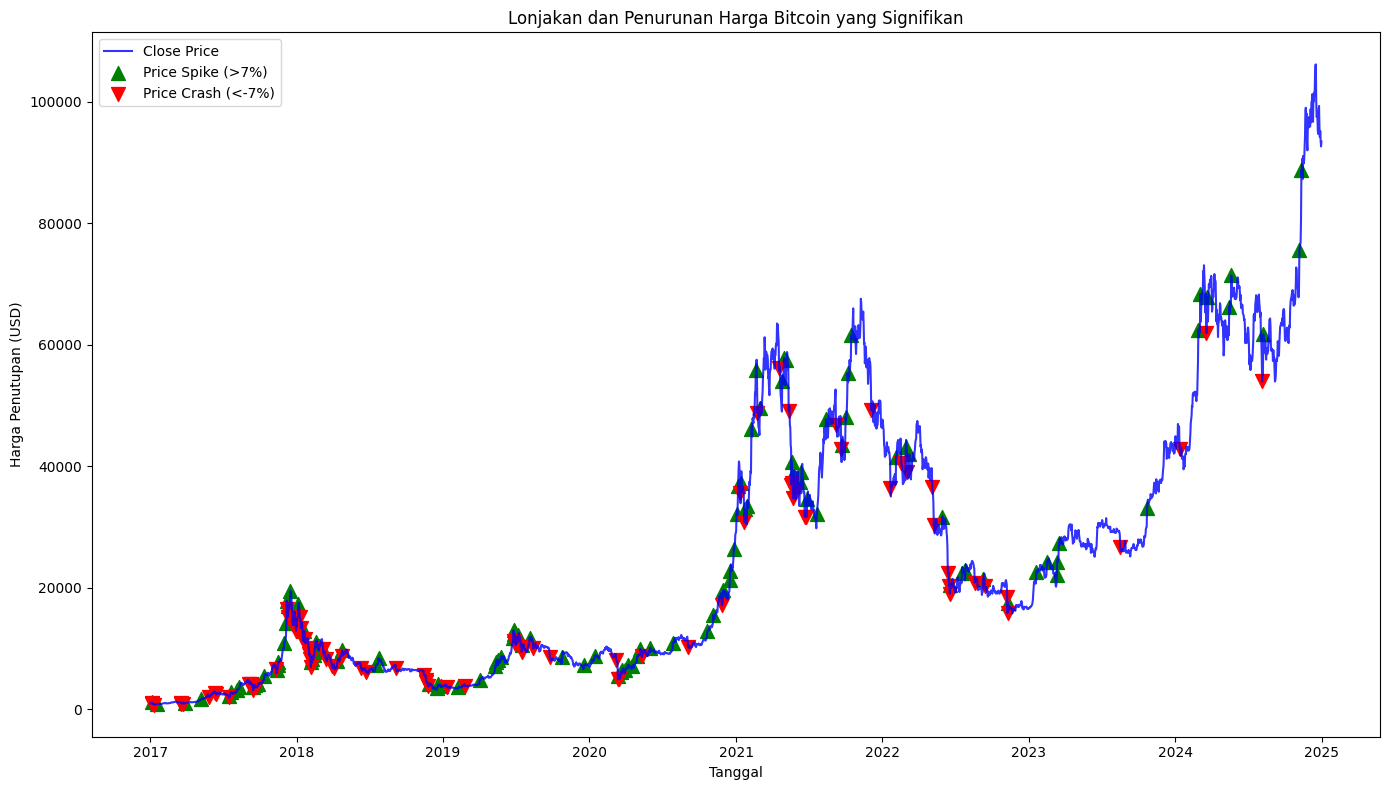

In [ ]:
# df_eda = df_eda.reset_index()
df_eda['Date'] = pd.to_datetime(df_eda['Date'], dayfirst=True)
df_eda.sort_values('Date', inplace=True)
df_eda.set_index('Date', inplace=True)

# Hitung return harian (% perubahan harga)
df_eda['Daily_Return'] = df_eda['Close'].pct_change() * 100  # persen

# Tentukan threshold spike & crash (misalnya lonjakan > 7%, penurunan < -7%)
spike_threshold = 7
crash_threshold = -7

df_eda['Spike'] = df_eda['Daily_Return'] > spike_threshold
df_eda['Crash'] = df_eda['Daily_Return'] < crash_threshold

# Plot harga Bitcoin dan tandai spike & crash
plt.figure(figsize=(14, 8))
plt.plot(df_eda.index, df_eda['Close'], label='Close Price', color='blue', alpha=0.8)

# Tandai lonjakan
plt.scatter(df_eda[df_eda['Spike']].index, df_eda[df_eda['Spike']]['Close'],
            color='green', label='Price Spike (>7%)', marker='^', s=100)

# Tandai penurunan drastis
plt.scatter(df_eda[df_eda['Crash']].index, df_eda[df_eda['Crash']]['Close'],
            color='red', label='Price Crash (<-7%)', marker='v', s=100)

plt.title('Lonjakan dan Penurunan Harga Bitcoin yang Signifikan')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan (USD)')
plt.legend()
plt.tight_layout()
plt.show()


## **5. Respons Volatilitas Terhadap Peristiwa Besar (misalnya: halving, pandemi, regulasi besar, dll)**



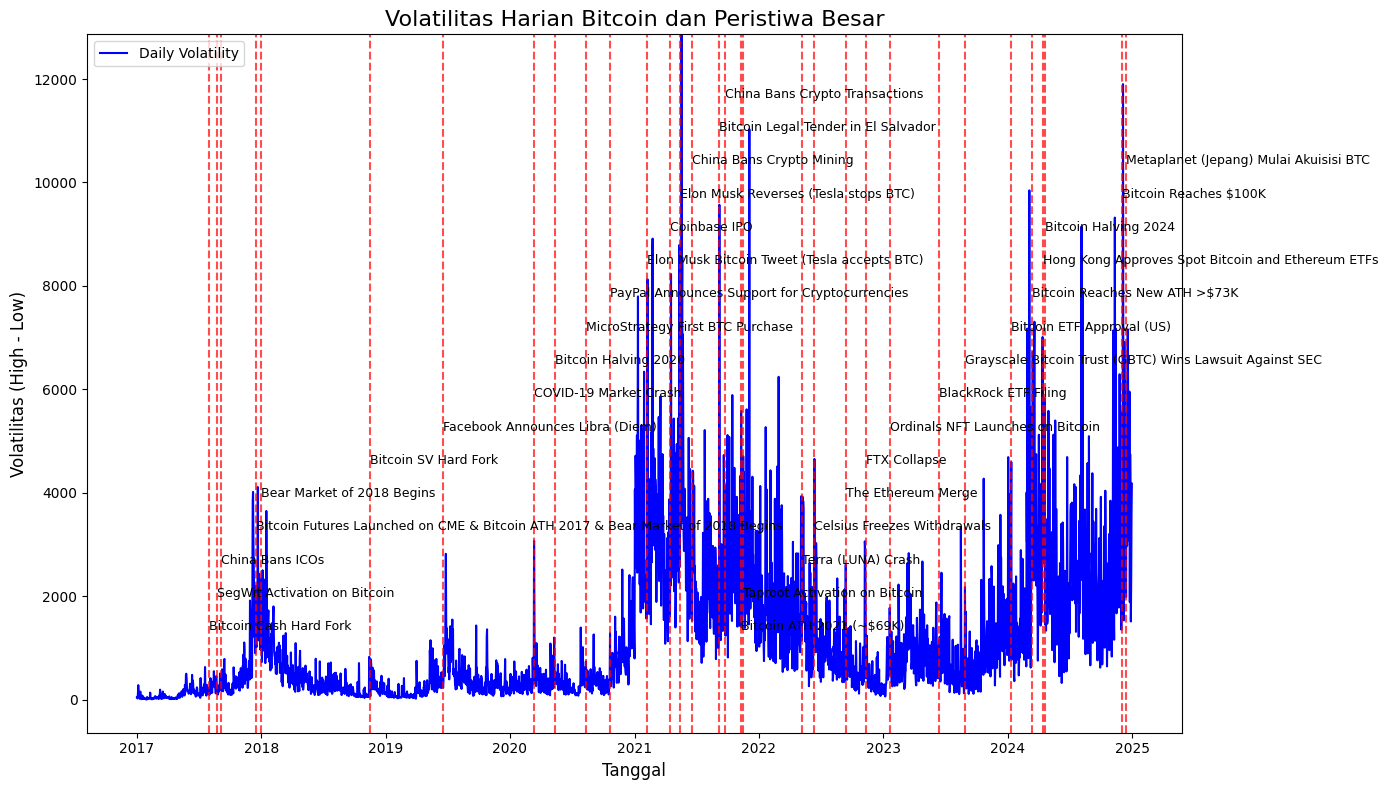

In [ ]:
df_eda = df_eda.reset_index()
df_eda['Date'] = pd.to_datetime(df_eda['Date'], dayfirst=True)
df_eda.set_index('Date', inplace=True)

# Hitung volatilitas harian jika belum ada
df_eda['Volatility'] = df_eda['High'] - df_eda['Low']

# Event besar (kamu bisa tambahkan atau ganti sesuai data aktual)
events = {
    # 2017
    'Bitcoin Cash Hard Fork': '2017-08-01',  # Tambahan
    'SegWit Activation on Bitcoin': '2017-08-23',
    '\nChina Bans ICOs': '2017-09-04',
    'Bitcoin Futures Launched on CME & Bitcoin ATH 2017 & Bear Market of 2018 Begins': '2017-12-17',
    # 'Bitcoin ATH 2017': '2017-12-17',

    # 2018
    'Bear Market of 2018 Begins': '2018-01-01',  # Perkiraan awal bear market
    'Bitcoin SV Hard Fork': '2018-11-15',  # Tambahan

    # 2019
    'Facebook Announces Libra (Diem)': '2019-06-18',

    # 2020
    'COVID-19 Market Crash': '2020-03-12',
    'Bitcoin Halving 2020': '2020-05-11',
    'MicroStrategy First BTC Purchase': '2020-08-11',  # Tambahan
    '\nPayPal Announces Support for Cryptocurrencies': '2020-10-21',

    # 2021
    'Elon Musk Bitcoin Tweet (Tesla accepts BTC)': '2021-02-08',
    'Coinbase IPO': '2021-04-14',
    'Elon Musk Reverses (Tesla stops BTC)': '2021-05-13',
    'China Bans Crypto Mining': '2021-06-18',
    'Bitcoin Legal Tender in El Salvador': '2021-09-07',
    'China Bans Crypto Transactions': '2021-09-24',
    'Bitcoin ATH 2021 (~$69K)': '2021-11-10',  # Tambahan
    'Taproot Activation on Bitcoin': '2021-11-14',

    # 2022
    'Terra (LUNA) Crash': '2022-05-09',
    'Celsius Freezes Withdrawals': '2022-06-13',
    'The Ethereum Merge': '2022-09-15',  # Tambahan
    'FTX Collapse': '2022-11-11',

    # 2023
    'Ordinals NFT Launches on Bitcoin': '2023-01-20',  # Perkiraan awal pencatatan ordinal inscription
    'BlackRock ETF Filing': '2023-06-15',
    'Grayscale Bitcoin Trust (GBTC) Wins Lawsuit Against SEC': '2023-08-29',

    # 2024
    'Bitcoin ETF Approval (US)': '2024-01-10',
    'Bitcoin Reaches New ATH >$73K': '2024-03-14',
    'Hong Kong Approves Spot Bitcoin and Ethereum ETFs': '2024-04-15',
    'Bitcoin Halving 2024': '2024-04-20',
    'Bitcoin Reaches $100K': '2024-12-01',  # Perkiraan berdasarkan laporan pasar
    'Metaplanet (Jepang) Mulai Akuisisi BTC': '2024-12-15',  # Periode awal pembelian besar-besaran BTC oleh perusahaan Jepang
}

# Plot volatilitas harian
plt.figure(figsize=(14, 8)) # Sedikit diperbesar agar label lebih muat
plt.plot(df_eda.index, df_eda['Volatility'], label='Daily Volatility', color='blue')

# --- MODIFIKASI DIMULAI DI SINI ---

# 1. Tentukan posisi awal Y dan seberapa besar kenaikannya setiap langkah
initial_y_position = df_eda['Volatility'].max() * 0.1  # Mulai dari 10% ketinggian maksimum
y_increment = df_eda['Volatility'].max() * 0.05       # Setiap label naik sebesar 5% dari ketinggian maks
current_y_position = initial_y_position

# 2. Loop dengan posisi Y yang dinamis
for event, date_str in events.items():
    event_date = pd.to_datetime(date_str)
    if event_date in df_eda.index:
        plt.axvline(event_date, color='red', linestyle='--', alpha=0.7)

        # Gunakan posisi Y saat ini untuk menempatkan teks
        plt.text(event_date, current_y_position, event, rotation=0, verticalalignment='bottom', fontsize=9)

        # Naikkan posisi Y untuk label berikutnya
        current_y_position += y_increment

        # Jika posisi Y terlalu tinggi, reset kembali ke bawah agar tidak keluar dari chart
        if current_y_position > df_eda['Volatility'].max() * 0.95:
            current_y_position = initial_y_position

# --- MODIFIKASI SELESAI ---

plt.title('Volatilitas Harian Bitcoin dan Peristiwa Besar', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Volatilitas (High - Low)', fontsize=12)
plt.ylim(top=df_eda['Volatility'].max() * 1) # Beri ruang lebih di atas untuk label
plt.tight_layout()
plt.legend()
plt.show()

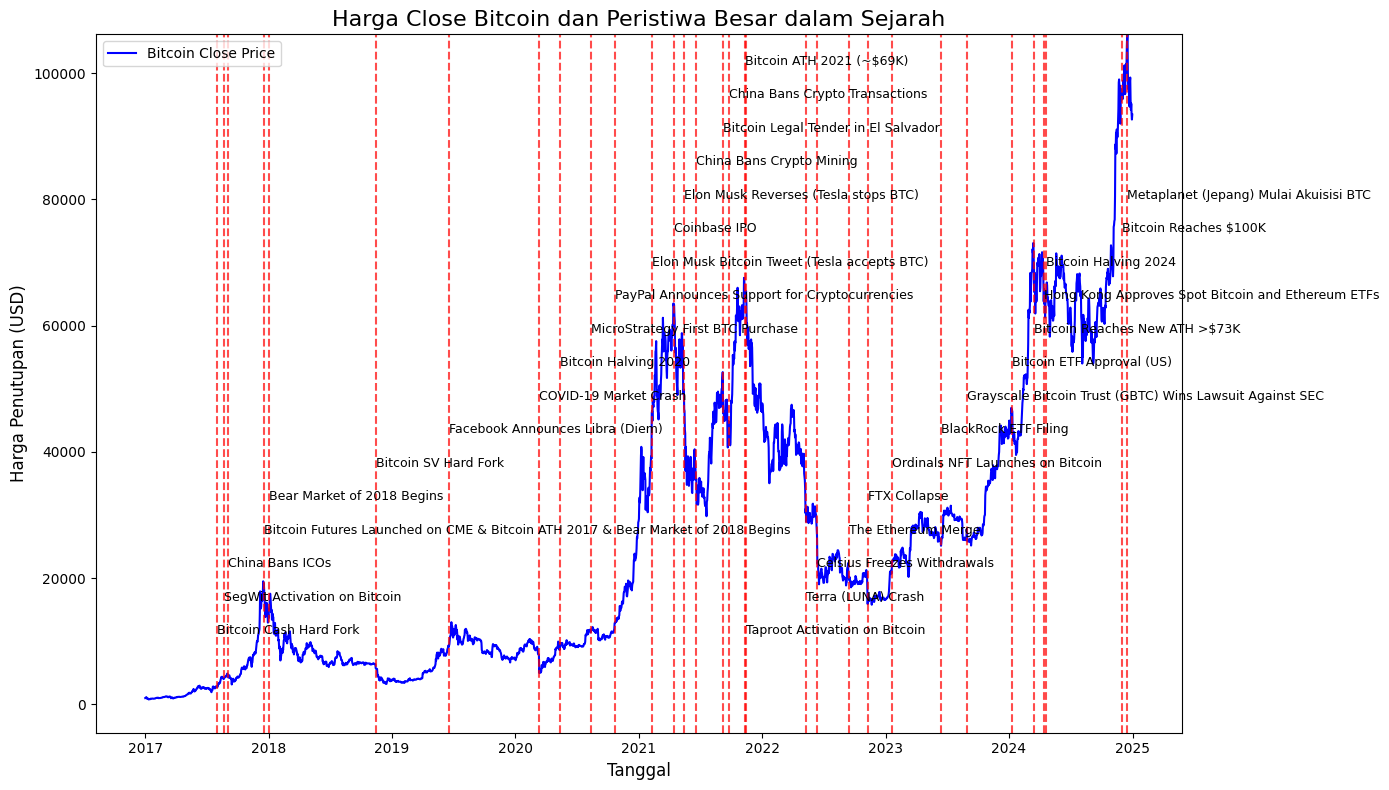

In [ ]:

# Plot harga penutupan (Close)
plt.figure(figsize=(14, 8))
plt.plot(df_eda.index, df_eda['Close'], label='Bitcoin Close Price', color='blue')

# --- MODIFIKASI DIMULAI DI SINI ---

# 1. Tentukan posisi awal Y dan seberapa besar kenaikannya setiap langkah
initial_y_position = df_eda['Close'].max() * 0.1  # Mulai dari 10% ketinggian maksimum
y_increment = df_eda['Close'].max() * 0.05       # Setiap label naik sebesar 5% dari ketinggian maks
current_y_position = initial_y_position

# 2. Loop dengan posisi Y yang dinamis
for event, date_str in events.items():
    event_date = pd.to_datetime(date_str)
    if event_date in df_eda.index:
        plt.axvline(event_date, color='red', linestyle='--', alpha=0.7)

        # Gunakan posisi Y saat ini untuk menempatkan teks
        plt.text(event_date, current_y_position, event, rotation=0, verticalalignment='bottom', fontsize=9)

        # Naikkan posisi Y untuk label berikutnya
        current_y_position += y_increment

        # Jika posisi Y terlalu tinggi, reset kembali ke bawah agar tidak keluar dari chart
        if current_y_position > df_eda['Close'].max() * 0.95:
            current_y_position = initial_y_position

# --- MODIFIKASI SELESAI ---

plt.title('Harga Close Bitcoin dan Peristiwa Besar dalam Sejarah', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Penutupan (USD)', fontsize=12)
plt.ylim(top=df_eda['Close'].max() * 1) # Beri ruang lebih di atas untuk label
plt.tight_layout()
plt.legend()
plt.show()

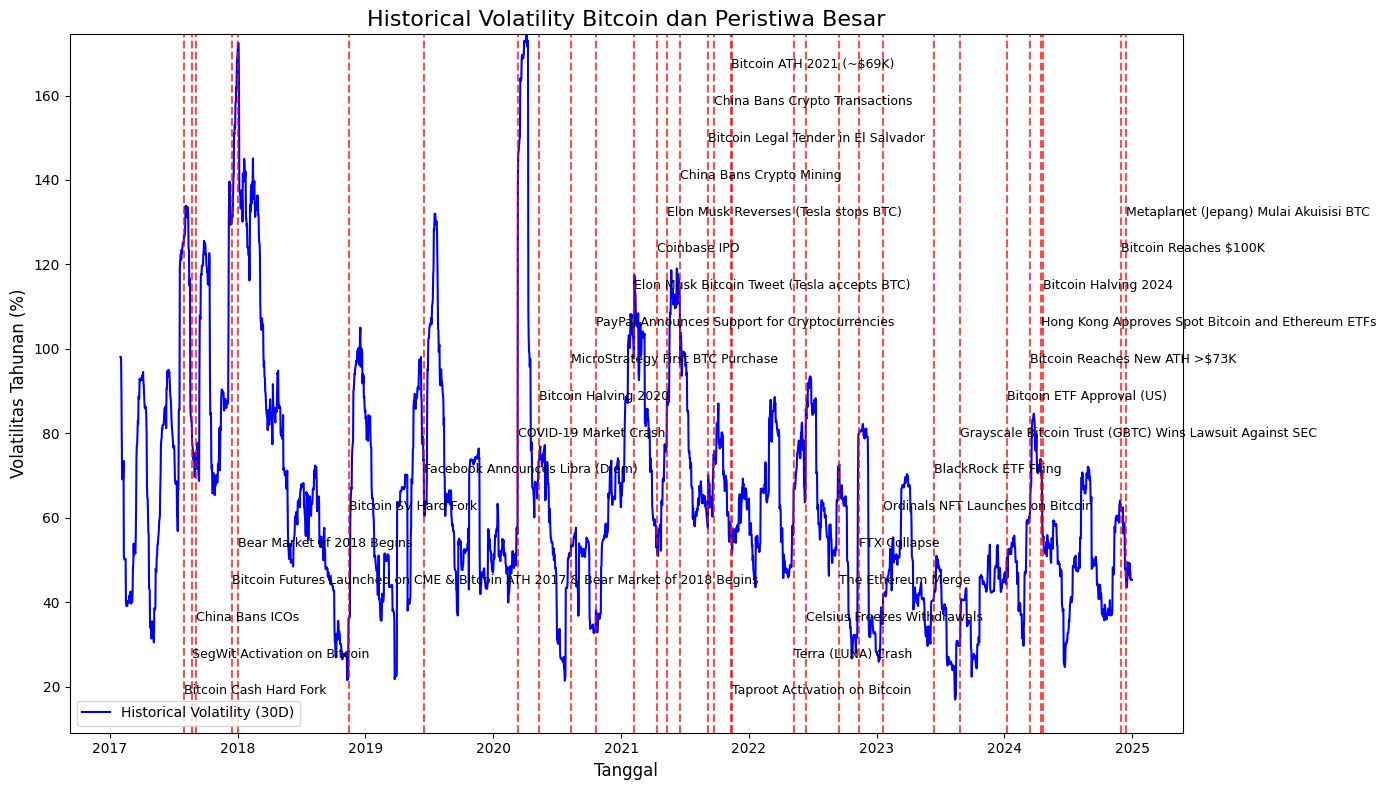

In [ ]:
# Return harian
df_eda['Daily_Return'] = df_eda['Close'].pct_change()

# Historical Volatility 30 hari (dalam persentase tahunan)
window = 30
trading_days = 365  # karena crypto beroperasi 24/7
df_eda['HV_30D'] = df_eda['Daily_Return'].rolling(window=window).std() * np.sqrt(trading_days) * 100


plt.figure(figsize=(14, 8))
plt.plot(df_eda['HV_30D'], label='Historical Volatility (30D)', color='blue')

# 1. Tentukan posisi awal Y dan seberapa besar kenaikannya setiap langkah
initial_y_position = df_eda['HV_30D'].max() * 0.1  # Mulai dari 10% ketinggian maksimum
y_increment = df_eda['HV_30D'].max() * 0.05       # Setiap label naik sebesar 5% dari ketinggian maks
current_y_position = initial_y_position

# 2. Loop dengan posisi Y yang dinamis
for event, date_str in events.items():
    event_date = pd.to_datetime(date_str)
    if event_date in df_eda.index:
        plt.axvline(event_date, color='red', linestyle='--', alpha=0.7)

        # Gunakan posisi Y saat ini untuk menempatkan teks
        plt.text(event_date, current_y_position, event, rotation=0, verticalalignment='bottom', fontsize=9)

        # Naikkan posisi Y untuk label berikutnya
        current_y_position += y_increment

        # Jika posisi Y terlalu tinggi, reset kembali ke bawah agar tidak keluar dari chart
        if current_y_position > df_eda['HV_30D'].max() * 0.95:
            current_y_position = initial_y_position

# --- MODIFIKASI SELESAI ---

plt.title('Historical Volatility Bitcoin dan Peristiwa Besar', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Volatilitas Tahunan (%)', fontsize=12)
plt.ylim(top=df_eda['HV_30D'].max() * 1) # Beri ruang lebih di atas untuk label
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# # Return harian
# df_eda['Daily_Return'] = df_eda['Close'].pct_change()

# # Historical Volatility 30 hari (dalam persentase tahunan)
# window = 30
# trading_days = 365  # karena crypto beroperasi 24/7
# df_eda['HV_30D'] = df_eda['Daily_Return'].rolling(window=window).std() * np.sqrt(trading_days) * 100

# # # Plot
# # plt.figure(figsize=(12, 6))
# # plt.plot(df_eda['HV_30D'], label='30-Day Historical Volatility', color='purple')
# # plt.title('30-Day Historical Volatility (Annualized) of Bitcoin')
# # plt.ylabel('Volatilitas (%)')
# # plt.xlabel('Tanggal')
# # plt.legend()
# # plt.tight_layout()
# # plt.show()

# plt.figure(figsize=(14, 6))
# plt.plot(df_eda['HV_30D'], label='Historical Volatility (30D)', color='purple')

# # Tambahkan event besar
# for event, date_str in events.items():
#     date = pd.to_datetime(date_str)
#     if date in df_eda.index:
#         plt.axvline(date, color='red', linestyle='--', alpha=0.5)
#         plt.text(date, df_eda['HV_30D'].max() * 0.9, event, rotation=90, fontsize=8, verticalalignment='center')

# plt.title('Historical Volatility Bitcoin dan Peristiwa Besar')
# plt.ylabel('Volatilitas Tahunan (%)')
# plt.xlabel('Tanggal')
# plt.legend()
# plt.tight_layout()
# plt.show()


## **6. Heatmap Rolling Volatility per Bulan dan Tahun**

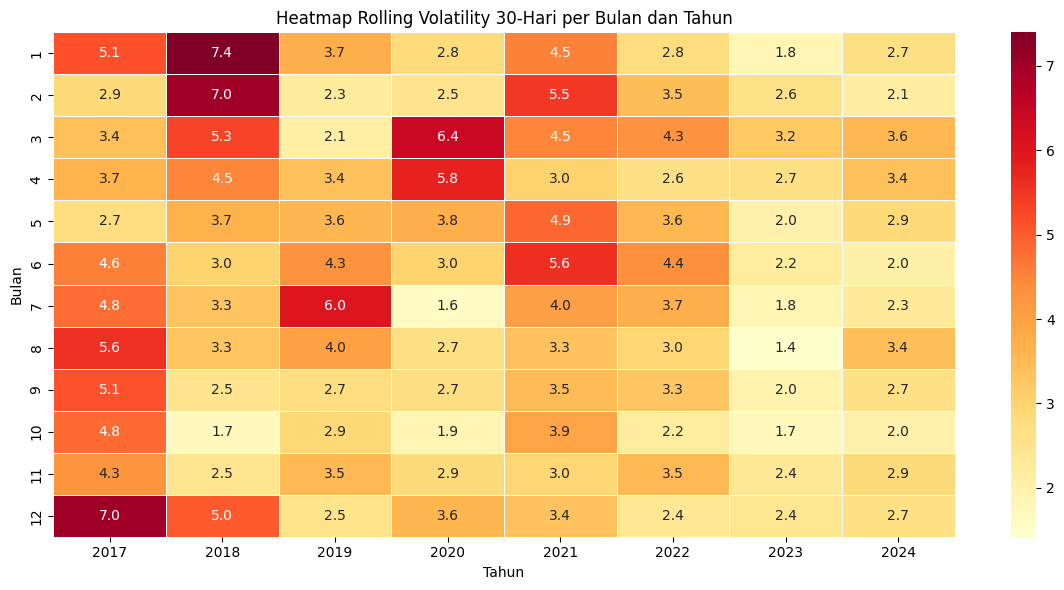

In [ ]:
# Siapkan rolling volatility
df_eda['RollingVol_30D'] = df_eda['Daily_Return'].rolling(window=30).std() * 100

# Tambah informasi waktu
df_eda['Year'] = df_eda.index.year
df_eda['Month'] = df_eda.index.month

# Ambil rata-rata rolling volatility per bulan-tahun
heatmap_data = df_eda.pivot_table(values='RollingVol_30D', index='Month', columns='Year', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".1f", linewidths=0.5)
plt.title('Heatmap Rolling Volatility 30-Hari per Bulan dan Tahun')
plt.ylabel('Bulan')
plt.xlabel('Tahun')
plt.tight_layout()
plt.show()


## **7. Overlay Harga Bitcoin vs Rolling Volatility**

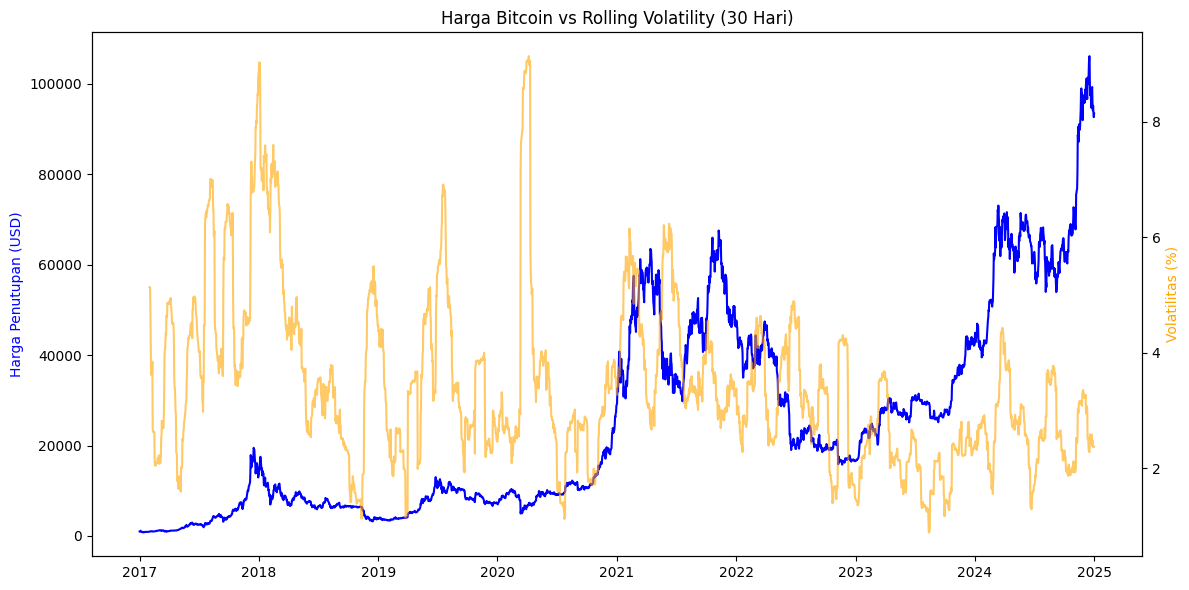

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Harga
ax1.plot(df_eda.index, df_eda['Close'], color='blue', label='Harga Penutupan')
ax1.set_ylabel('Harga Penutupan (USD)', color='blue')

# Volatilitas
ax2 = ax1.twinx()
ax2.plot(df_eda.index, df_eda['RollingVol_30D'], color='orange', label='Rolling Volatility (30D)', alpha=0.6)
ax2.set_ylabel('Volatilitas (%)', color='orange')

plt.title('Harga Bitcoin vs Rolling Volatility (30 Hari)')
fig.tight_layout()
plt.show()


# ARIMA

In [ ]:
df_arima_biasa = df.copy()
df_arima_biasa

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


In [ ]:
# Target series
y_raw = df_arima_biasa[['Close']]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Sebelum differencing
result_before = adfuller(df_arima_biasa['Close'])
print('Sebelum Differencing:')
print('ADF Statistic:', result_before[0])
print('p-value:', result_before[1])
if result_before[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

# Differencing
df_arima_biasa['Close_diff1'] = df_arima_biasa['Close'].diff()  # Menghilangkan pola

# Menghapus nilai NaN yang dihasilkan oleh differencing
df_arima_biasa.dropna(inplace=True)

# Setelah differencing
result_after = adfuller(df_arima_biasa['Close_diff1'])
print('\nSetelah Differencing:')
print('ADF Statistic:', result_after[0])
print('p-value:', result_after[1])
if result_after[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

Sebelum Differencing:
ADF Statistic: 0.0012839333152797835
p-value: 0.9586381377359496
Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)

Setelah Differencing:
ADF Statistic: -8.858429370184508
p-value: 1.5056621117325513e-14
Hasil uji menunjukkan deret waktu stasioner (Tolak H0)


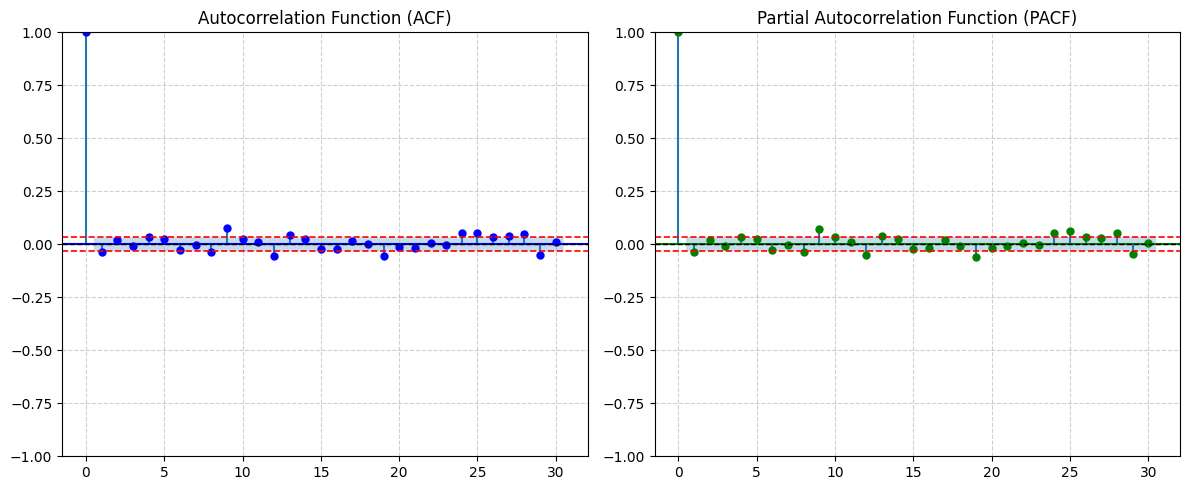

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set level signifikansi
significance_level = 0.05

# Ukuran figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ACF Plot
sm.graphics.tsa.plot_acf(df_arima_biasa['Close_diff1'], lags=30, alpha=significance_level, ax=ax1, color='blue')
ax1.axhline(y=0, linestyle='--', color='black', linewidth=1)  # Garis tengah
ax1.axhline(y=1.96/np.sqrt(len(df_arima_biasa['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas atas signifikan
ax1.axhline(y=-1.96/np.sqrt(len(df_arima_biasa['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas bawah signifikan
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_title('Autocorrelation Function (ACF)', fontsize=12)

# PACF Plot
sm.graphics.tsa.plot_pacf(df_arima_biasa['Close_diff1'], lags=30, alpha=significance_level, ax=ax2, color='green')
ax2.axhline(y=0, linestyle='--', color='black', linewidth=1)  # Garis tengah
ax2.axhline(y=1.96/np.sqrt(len(df_arima_biasa['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas atas signifikan
ax2.axhline(y=-1.96/np.sqrt(len(df_arima_biasa['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas bawah signifikan
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_title('Partial Autocorrelation Function (PACF)', fontsize=12)

# Menyesuaikan tata letak
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf, pacf

# Data
y = df_arima_biasa['Close_diff1'].dropna()

# Hitung ACF dan PACF (tanpa confint)
nlags = 30
acf_values = acf(y, nlags=nlags)
pacf_values = pacf(y, nlags=nlags)

# Batas signifikansi manual
N = len(y)
z = 1.96  # 95% CI
threshold = z / np.sqrt(N)

# Cek lag signifikan ACF
acf_significant = []
for lag in range(1, nlags+1):
    val = acf_values[lag]
    if abs(val) > threshold:
        acf_significant.append({'Lag': lag, 'ACF': val})

# Cek lag signifikan PACF
pacf_significant = []
for lag in range(1, nlags+1):
    val = pacf_values[lag]
    if abs(val) > threshold:
        pacf_significant.append({'Lag': lag, 'PACF': val})

acf_df = pd.DataFrame(acf_significant)
pacf_df = pd.DataFrame(pacf_significant)

print("\nLAG ACF yang signifikan:")
print(acf_df)

print("\nLAG PACF yang signifikan:")
print(pacf_df)



LAG ACF yang signifikan:
    Lag       ACF
0     1 -0.034384
1     4  0.033134
2     8 -0.037804
3     9  0.076078
4    12 -0.054055
5    13  0.044096
6    19 -0.053835
7    24  0.051412
8    25  0.051026
9    26  0.033734
10   27  0.037490
11   28  0.048912
12   29 -0.050516

LAG PACF yang signifikan:
    Lag      PACF
0     1 -0.034394
1     8 -0.037988
2     9  0.072242
3    10  0.033161
4    12 -0.052672
5    13  0.037509
6    19 -0.058195
7    24  0.052184
8    25  0.064267
9    26  0.034864
10   28  0.055739
11   29 -0.045884


In [ ]:
acf_df

,Lag,ACF
0,1,-0.034384
1,4,0.033134
2,8,-0.037804
3,9,0.076078
4,12,-0.054055
5,13,0.044096
6,19,-0.053835
7,24,0.051412
8,25,0.051026
9,26,0.033734


In [ ]:
pacf_df

,Lag,PACF
0,1,-0.034394
1,8,-0.037988
2,9,0.072242
3,10,0.033161
4,12,-0.052672
5,13,0.037509
6,19,-0.058195
7,24,0.052184
8,25,0.064267
9,26,0.034864


In [ ]:
# Scaling (optional, boleh skip kalau datanya tidak meledak)
sc_y = MinMaxScaler()
y_scaled = pd.DataFrame(sc_y.fit_transform(y_raw), index=y_raw.index, columns=['Close_scaled'])


In [ ]:
# Split train-test
train_end = '2023-12-31'
y_train = y_scaled[:train_end]
y_test = y_scaled[train_end:]

## ARIMA(1,1,1)

In [ ]:
# ARIMA: pakai (p,d,q) dari ACF/PACF
model_arima_biasa = ARIMA(y_train, order=(1, 1, 1))
results_arima_biasa = model_arima_biasa.fit()
print(results_arima_biasa.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Close_scaled   No. Observations:                 3287
Model:                 ARIMA(1, 1, 1)   Log Likelihood               11420.473
Date:                Wed, 23 Jul 2025   AIC                         -22834.946
Time:                        08:37:14   BIC                         -22816.654
Sample:                    01-01-2015   HQIC                        -22828.397
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1050      0.339     -0.310      0.757      -0.770       0.560
ma.L1          0.0788      0.340      0.231      0.817      -0.588       0.746
sigma2      5.607e-05   4.69e-07    119.599      0.0

In [ ]:
# Prediksi ke depan (out-of-sample)
pred_scaled = results_arima_biasa.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)

# Balik ke skala asli
pred_biasa = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
actual_biasa = sc_y.inverse_transform(y_test.values)

# Evaluasi model
mae = mean_absolute_error(actual_biasa, pred_biasa)
rmse = np.sqrt(mean_squared_error(actual_biasa, pred_biasa))
mape = np.mean(np.abs((actual_biasa - pred_biasa) / actual_biasa)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 23712.6578
Root Mean Squared Error (RMSE): 27832.2182
Mean Absolute Percentage Error (MAPE): 32.96%


## ARIMA(0,1,1)

In [ ]:
# ARIMA: pakai (p,d,q) dari ACF/PACF
model_arima_biasa = ARIMA(y_train, order=(0, 1, 1))
results_arima_biasa2 = model_arima_biasa.fit()
print(results_arima_biasa2.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Close_scaled   No. Observations:                 3287
Model:                 ARIMA(0, 1, 1)   Log Likelihood               11420.395
Date:                Wed, 23 Jul 2025   AIC                         -22836.790
Time:                        08:37:15   BIC                         -22824.595
Sample:                    01-01-2015   HQIC                        -22832.424
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0262      0.009     -2.834      0.005      -0.044      -0.008
sigma2      5.607e-05   4.63e-07    121.113      0.000    5.52e-05     5.7e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

In [ ]:
# Prediksi ke depan (out-of-sample)
pred_scaled = results_arima_biasa2.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)

# Balik ke skala asli
pred_biasa = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
actual_biasa = sc_y.inverse_transform(y_test.values)

# Evaluasi model
mae = mean_absolute_error(actual_biasa, pred_biasa)
rmse = np.sqrt(mean_squared_error(actual_biasa, pred_biasa))
mape = np.mean(np.abs((actual_biasa - pred_biasa) / actual_biasa)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 23713.1008
Root Mean Squared Error (RMSE): 27832.6213
Mean Absolute Percentage Error (MAPE): 32.96%


## ARIMA(1,1,0)

In [ ]:
# ARIMA: pakai (p,d,q) dari ACF/PACF
model_arima_biasa = ARIMA(y_train, order=(1, 1, 0))
results_arima_biasa3 = model_arima_biasa.fit()
print(results_arima_biasa3.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Close_scaled   No. Observations:                 3287
Model:                 ARIMA(1, 1, 0)   Log Likelihood               11420.420
Date:                Wed, 23 Jul 2025   AIC                         -22836.840
Time:                        08:37:15   BIC                         -22824.645
Sample:                    01-01-2015   HQIC                        -22832.474
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0263      0.009     -2.845      0.004      -0.044      -0.008
sigma2      5.607e-05   4.63e-07    121.091      0.000    5.52e-05     5.7e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

In [ ]:
# Prediksi ke depan (out-of-sample)
pred_scaled = results_arima_biasa3.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)

# Balik ke skala asli
pred_biasa = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
actual_biasa = sc_y.inverse_transform(y_test.values)

# Evaluasi model
mae = mean_absolute_error(actual_biasa, pred_biasa)
rmse = np.sqrt(mean_squared_error(actual_biasa, pred_biasa))
mape = np.mean(np.abs((actual_biasa - pred_biasa) / actual_biasa)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 23713.0113
Root Mean Squared Error (RMSE): 27832.5398
Mean Absolute Percentage Error (MAPE): 32.96%


## Visualisasi ARIMA

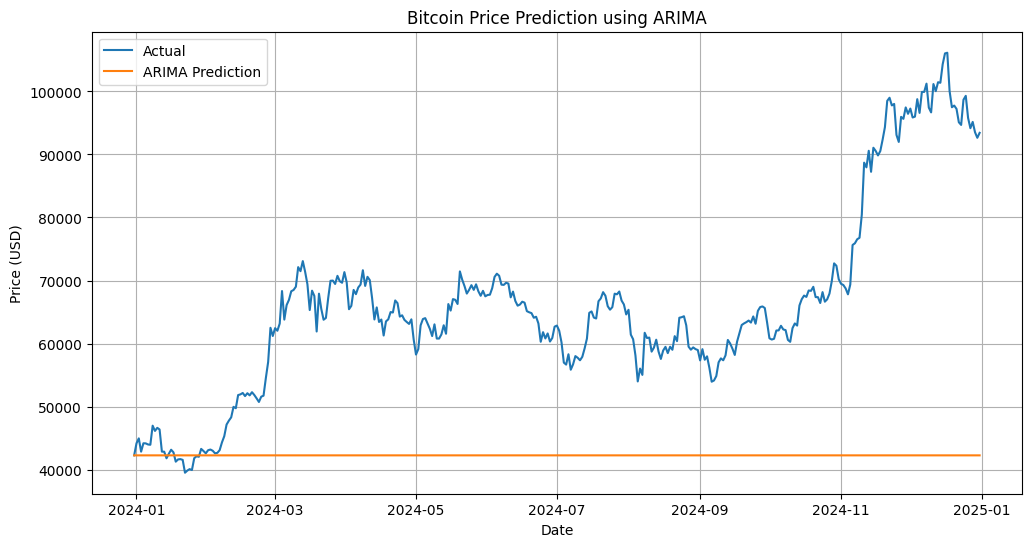

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, actual_biasa, label='Actual')
plt.plot(y_test.index, pred_biasa, label='ARIMA Prediction')
plt.legend()
plt.title('Bitcoin Price Prediction using ARIMA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


In [ ]:
# Evaluasi model
mae = mean_absolute_error(actual_biasa, pred_biasa)
rmse = np.sqrt(mean_squared_error(actual_biasa, pred_biasa))
mape = np.mean(np.abs((actual_biasa - pred_biasa) / actual_biasa)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 23713.0113
Root Mean Squared Error (RMSE): 27832.5398
Mean Absolute Percentage Error (MAPE): 32.96%


# ARIMAX Lag Input

In [ ]:
df_arim = df.copy()
df_arim

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Sebelum differencing
result_before = adfuller(df_arim['Close'])
print('Sebelum Differencing:')
print('ADF Statistic:', result_before[0])
print('p-value:', result_before[1])
if result_before[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

# Differencing
df_arim['Close_diff1'] = df_arim['Close'].diff()  # Menghilangkan pola

# Menghapus nilai NaN yang dihasilkan oleh differencing
df_arim.dropna(inplace=True)

# Setelah differencing
result_after = adfuller(df_arim['Close_diff1'])
print('\nSetelah Differencing:')
print('ADF Statistic:', result_after[0])
print('p-value:', result_after[1])
if result_after[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

Sebelum Differencing:
ADF Statistic: 0.0012839333152797835
p-value: 0.9586381377359496
Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)

Setelah Differencing:
ADF Statistic: -8.858429370184508
p-value: 1.5056621117325513e-14
Hasil uji menunjukkan deret waktu stasioner (Tolak H0)


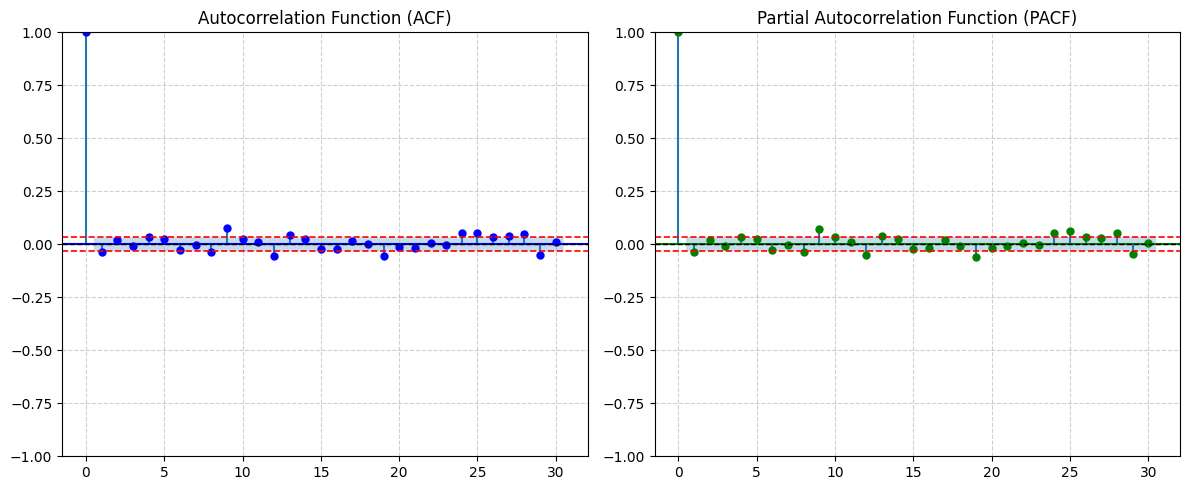

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set level signifikansi
significance_level = 0.05

# Ukuran figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ACF Plot
sm.graphics.tsa.plot_acf(df_arim['Close_diff1'], lags=30, alpha=significance_level, ax=ax1, color='blue')
ax1.axhline(y=0, linestyle='--', color='black', linewidth=1)  # Garis tengah
ax1.axhline(y=1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas atas signifikan
ax1.axhline(y=-1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas bawah signifikan
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_title('Autocorrelation Function (ACF)', fontsize=12)

# PACF Plot
sm.graphics.tsa.plot_pacf(df_arim['Close_diff1'], lags=30, alpha=significance_level, ax=ax2, color='green')
ax2.axhline(y=0, linestyle='--', color='black', linewidth=1)  # Garis tengah
ax2.axhline(y=1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas atas signifikan
ax2.axhline(y=-1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas bawah signifikan
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_title('Partial Autocorrelation Function (PACF)', fontsize=12)

# Menyesuaikan tata letak
plt.tight_layout()
plt.show()


In [ ]:
# Mean dan fitur lag
df_arim['Mean'] = (df_arim['Low'] + df_arim['High']) / 2
df_arim['Actual'] = df_arim['Mean'].shift()


## **Jangan DI RUN!!!**

In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Daftar lag signifikan dari PACF
significant_lags = [8, 9, 10, 13, 19, 24, 25]

all_significant_combos = []

for lag_comb in combinations(significant_lags, 3):  # ganti jadi 5 jika ingin 5 lag
    df_temp = df_arim.copy()

    # Tambahkan kolom lag
    for lag in lag_comb:
        df_temp[f'Close_lag_{lag}'] = df_temp['Close'].shift(lag)

    df_temp.dropna(inplace=True)

    # Exogenous features hanya lag
    feature_cols = [f'Close_lag_{lag}' for lag in lag_comb]
    X = df_temp[feature_cols]
    y = df_temp[['Actual']]

    # Scaling
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_scaled = pd.DataFrame(sc_X.fit_transform(X), index=X.index, columns=feature_cols)
    y_scaled = pd.DataFrame(sc_y.fit_transform(y), index=y.index, columns=['BTC Price next day'])

    # Train-test split
    train_end = '2023-12-31'
    X_train = X_scaled[:train_end]
    X_test = X_scaled[train_end:]
    y_train = y_scaled[:train_end]
    y_test = y_scaled[train_end:]

    try:
        model = ARIMA(endog=y_train, exog=X_train, order=(1, 1, 0))
        result = model.fit()

        print(f"\n🔹 Kombinasi lag: {lag_comb}")
        print("P-values dan Kriteria Signifikansi:")

        pvals = result.pvalues.round(4)
        all_signif = True

        for param, pval in pvals.items():
            signif = "Signifikan" if pval < 0.05 else "Tidak signifikan"
            print(f"{param}: {pval:.4f} → {signif}")
            if pval >= 0.05:
                all_signif = False

        # Jika semua signifikan, tampilkan summary dan metrik evaluasi
        if all_signif:
            all_significant_combos.append(lag_comb)

            # Evaluasi
            pred_scaled = result.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog=X_test)
            pred_inv = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
            actual_inv = sc_y.inverse_transform(y_test.values)

            mae = mean_absolute_error(actual_inv, pred_inv)
            rmse = np.sqrt(mean_squared_error(actual_inv, pred_inv))
            mape = np.mean(np.abs((actual_inv - pred_inv) / actual_inv)) * 100

            print("\n📊 Evaluasi Model:")
            print(f"MAE  : {mae:.4f}")
            print(f"RMSE : {rmse:.4f}")
            print(f"MAPE : {mape:.2f}%")

            print("\n📄 Summary Model:")
            print(result.summary())

    except Exception as e:
        print(f"❌ Error pada kombinasi {lag_comb}: {e}")
        continue

# Ringkasan akhir
print("\n✅ Daftar Kombinasi dengan Semua Parameter Signifikan:")
if all_significant_combos:
    for combo in all_significant_combos:
        print(f"🔸 {combo}")
else:
    print("❗Tidak ada kombinasi yang semua parameternya signifikan.")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (8, 9, 10)
P-values dan Kriteria Signifikansi:
Close_lag_8: 0.6079 → Tidak signifikan
Close_lag_9: 0.0000 → Signifikan
Close_lag_10: 0.1138 → Tidak signifikan
ar.L1: 0.0000 → Signifikan
sigma2: 0.0000 → Signifikan


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (8, 9, 13)
P-values dan Kriteria Signifikansi:
Close_lag_8: 0.5638 → Tidak signifikan
Close_lag_9: 0.0000 → Signifikan
Close_lag_13: 0.0064 → Signifikan
ar.L1: 0.0000 → Signifikan
sigma2: 0.0000 → Signifikan


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...


🔹 Kombinasi lag: (13, 19, 25)
P-values dan Kriteria Signifikansi:
Close_lag_13: 0.0061 → Signifikan
Close_lag_19: 0.7109 → Tidak signifikan
Close_lag_25: 0.0021 → Signifikan
ar.L1: 0.0000 → Signifikan
sigma2: 0.0000 → Signifikan


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (13, 24, 25)
P-values dan Kriteria Signifikansi:
Close_lag_13: 0.0060 → Signifikan
Close_lag_24: 0.0139 → Signifikan
Close_lag_25: 0.0035 → Signifikan
ar.L1: 0.0000 → Signifikan
sigma2: 0.0000 → Signifikan

📊 Evaluasi Model:
MAE  : 24030.6483
RMSE : 28190.9585
MAPE : 33.54%

📄 Summary Model:
                               SARIMAX Results                                
Dep. Variable:     BTC Price next day   No. Observations:                 3236
Model:                 ARIMA(1, 1, 0)   Log Likelihood               12052.646
Date:                Mon, 21 Jul 2025   AIC                         -24095.291
Time:                        08:38:44   BIC                         -24064.882
Sample:                    02-21-2015   HQIC                        -24084.395
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z| 

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (19, 24, 25)
P-values dan Kriteria Signifikansi:
Close_lag_19: 0.6924 → Tidak signifikan
Close_lag_24: 0.0128 → Signifikan
Close_lag_25: 0.0021 → Signifikan
ar.L1: 0.0000 → Signifikan
sigma2: 0.0000 → Signifikan

✅ Daftar Kombinasi dengan Semua Parameter Signifikan:
🔸 (9, 13, 24)
🔸 (9, 13, 25)
🔸 (9, 24, 25)
🔸 (10, 13, 25)
🔸 (13, 24, 25)


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Daftar lag signifikan dari PACF
significant_lags = [8, 9, 10, 13, 19, 24, 25]

all_significant_combos = []

for lag_comb in combinations(significant_lags, 3):  # ganti jadi 5 jika ingin 5 lag
    df_temp = df_arim.copy()

    # Tambahkan kolom lag
    for lag in lag_comb:
        df_temp[f'Close_lag_{lag}'] = df_temp['Close'].shift(lag)

    df_temp.dropna(inplace=True)

    # Exogenous features hanya lag
    feature_cols =  ['Low', 'High', 'Volume'] + [f'Close_lag_{lag}' for lag in lag_comb]
    X = df_temp[feature_cols]
    y = df_temp[['Actual']]

    # Scaling
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_scaled = pd.DataFrame(sc_X.fit_transform(X), index=X.index, columns=feature_cols)
    y_scaled = pd.DataFrame(sc_y.fit_transform(y), index=y.index, columns=['BTC Price next day'])

    # Train-test split
    train_end = '2023-12-31'
    X_train = X_scaled[:train_end]
    X_test = X_scaled[train_end:]
    y_train = y_scaled[:train_end]
    y_test = y_scaled[train_end:]

    try:
        model = ARIMA(endog=y_train, exog=X_train, order=(1, 1, 0))
        result = model.fit()

        print(f"\n🔹 Kombinasi lag: {lag_comb}")
        print("P-values dan Kriteria Signifikansi:")

        pvals = result.pvalues.round(4)
        all_signif = True

        for param, pval in pvals.items():
            signif = "Signifikan" if pval < 0.05 else "Tidak signifikan"
            print(f"{param}: {pval:.4f} → {signif}")
            if pval >= 0.05:
                all_signif = False

        # Jika semua signifikan, tampilkan summary dan metrik evaluasi
        if all_signif:
            all_significant_combos.append(lag_comb)

            # Evaluasi
            pred_scaled = result.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog=X_test)
            pred_inv = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
            actual_inv = sc_y.inverse_transform(y_test.values)

            mae = mean_absolute_error(actual_inv, pred_inv)
            rmse = np.sqrt(mean_squared_error(actual_inv, pred_inv))
            mape = np.mean(np.abs((actual_inv - pred_inv) / actual_inv)) * 100

            print("\n📊 Evaluasi Model:")
            print(f"MAE  : {mae:.4f}")
            print(f"RMSE : {rmse:.4f}")
            print(f"MAPE : {mape:.2f}%")

            print("\n📄 Summary Model:")
            print(result.summary())

    except Exception as e:
        print(f"❌ Error pada kombinasi {lag_comb}: {e}")
        continue

# Ringkasan akhir
print("\n✅ Daftar Kombinasi dengan Semua Parameter Signifikan:")
if all_significant_combos:
    for combo in all_significant_combos:
        print(f"🔸 {combo}")
else:
    print("❗Tidak ada kombinasi yang semua parameternya signifikan.")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (8, 9, 10)
P-values dan Kriteria Signifikansi:
Low: 0.0000 → Signifikan
High: 0.0000 → Signifikan
Volume: 0.0000 → Signifikan
Close_lag_8: 0.0017 → Signifikan
Close_lag_9: 0.0000 → Signifikan
Close_lag_10: 0.8982 → Tidak signifikan
ar.L1: 0.0573 → Tidak signifikan
sigma2: 0.0000 → Signifikan


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (8, 9, 13)
P-values dan Kriteria Signifikansi:
Low: 0.0000 → Signifikan
High: 0.0000 → Signifikan
Volume: 0.0000 → Signifikan
Close_lag_8: 0.0013 → Signifikan
Close_lag_9: 0.0000 → Signifikan
Close_lag_13: 0.1009 → Tidak signifikan
ar.L1: 0.0549 → Tidak signifikan
sigma2: 0.0000 → Signifikan


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...


🔹 Kombinasi lag: (13, 19, 25)
P-values dan Kriteria Signifikansi:
Low: 0.0000 → Signifikan
High: 0.0000 → Signifikan
Volume: 0.0000 → Signifikan
Close_lag_13: 0.0804 → Tidak signifikan
Close_lag_19: 0.2678 → Tidak signifikan
Close_lag_25: 0.0025 → Signifikan
ar.L1: 0.0269 → Signifikan
sigma2: 0.0000 → Signifikan


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (13, 24, 25)
P-values dan Kriteria Signifikansi:
Low: 0.0000 → Signifikan
High: 0.0000 → Signifikan
Volume: 0.0000 → Signifikan
Close_lag_13: 0.0842 → Tidak signifikan
Close_lag_24: 0.0180 → Signifikan
Close_lag_25: 0.0029 → Signifikan
ar.L1: 0.0316 → Signifikan
sigma2: 0.0000 → Signifikan


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (19, 24, 25)
P-values dan Kriteria Signifikansi:
Low: 0.0000 → Signifikan
High: 0.0000 → Signifikan
Volume: 0.0000 → Signifikan
Close_lag_19: 0.2596 → Tidak signifikan
Close_lag_24: 0.0158 → Signifikan
Close_lag_25: 0.0021 → Signifikan
ar.L1: 0.0324 → Signifikan
sigma2: 0.0000 → Signifikan

✅ Daftar Kombinasi dengan Semua Parameter Signifikan:
🔸 (8, 9, 25)
🔸 (8, 24, 25)
🔸 (9, 24, 25)


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Daftar lag signifikan dari PACF
significant_lags = [8]

all_significant_combos = []

for lag_comb in combinations(significant_lags, 1):  # ganti jadi 5 jika ingin 5 lag
    df_temp = df_arim.copy()

    # Tambahkan kolom lag
    for lag in lag_comb:
        df_temp[f'Close_lag_{lag}'] = df_temp['Close'].shift(lag)

    df_temp.dropna(inplace=True)

    # Exogenous features hanya lag
    feature_cols =  ['Low', 'High', 'Volume']
    X = df_temp[feature_cols]
    y = df_temp[['Actual']]

    # Scaling
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_scaled = pd.DataFrame(sc_X.fit_transform(X), index=X.index, columns=feature_cols)
    y_scaled = pd.DataFrame(sc_y.fit_transform(y), index=y.index, columns=['BTC Price next day'])

    # Train-test split
    train_end = '2023-12-31'
    X_train = X_scaled[:train_end]
    X_test = X_scaled[train_end:]
    y_train = y_scaled[:train_end]
    y_test = y_scaled[train_end:]

    try:
        model = ARIMA(endog=y_train, exog=X_train, order=(1, 1, 0))
        result = model.fit()

        print(f"\n🔹 Kombinasi lag: {lag_comb}")
        print("P-values dan Kriteria Signifikansi:")

        pvals = result.pvalues.round(4)
        all_signif = True

        for param, pval in pvals.items():
            signif = "Signifikan" if pval < 0.05 else "Tidak signifikan"
            print(f"{param}: {pval:.4f} → {signif}")
            if pval >= 0.05:
                all_signif = False

        # Jika semua signifikan, tampilkan summary dan metrik evaluasi
        if all_signif:
            all_significant_combos.append(lag_comb)

            # Evaluasi
            pred_scaled = result.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog=X_test)
            pred_inv = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
            actual_inv = sc_y.inverse_transform(y_test.values)

            mae = mean_absolute_error(actual_inv, pred_inv)
            rmse = np.sqrt(mean_squared_error(actual_inv, pred_inv))
            mape = np.mean(np.abs((actual_inv - pred_inv) / actual_inv)) * 100

            print("\n📊 Evaluasi Model:")
            print(f"MAE  : {mae:.4f}")
            print(f"RMSE : {rmse:.4f}")
            print(f"MAPE : {mape:.2f}%")

            print("\n📄 Summary Model:")
            print(result.summary())

    except Exception as e:
        print(f"❌ Error pada kombinasi {lag_comb}: {e}")
        continue

# Ringkasan akhir
print("\n✅ Daftar Kombinasi dengan Semua Parameter Signifikan:")
if all_significant_combos:
    for combo in all_significant_combos:
        print(f"🔸 {combo}")
else:
    print("❗Tidak ada kombinasi yang semua parameternya signifikan.")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



🔹 Kombinasi lag: (8,)
P-values dan Kriteria Signifikansi:
Low: 0.0000 → Signifikan
High: 0.0000 → Signifikan
Volume: 0.0000 → Signifikan
ar.L1: 0.0346 → Signifikan
sigma2: 0.0000 → Signifikan

📊 Evaluasi Model:
MAE  : 16495.5360
RMSE : 19380.1672
MAPE : 23.00%

📄 Summary Model:
                               SARIMAX Results                                
Dep. Variable:     BTC Price next day   No. Observations:                 3253
Model:                 ARIMA(1, 1, 0)   Log Likelihood               12177.573
Date:                Mon, 21 Jul 2025   AIC                         -24345.145
Time:                        09:34:36   BIC                         -24314.710
Sample:                    02-04-2015   HQIC                        -24334.243
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
lags = [8, 9, 10, 24, 25]
for lag in lags:
    df_arim[f'Close_lag_{lag}'] = df_arim['Close'].shift(lag)
df_arim.dropna(inplace=True)


In [ ]:
df_arim

,Close,High,Low,Open,Volume,Close_diff1,Mean,Actual,Close_lag_8,Close_lag_9,Close_lag_10,Close_lag_24,Close_lag_25
Date,,,,,,,,,,,,,
2015-01-27,263.475006,275.480011,250.653000,273.166992,4.439900e+07,-9.997986,263.066505,281.731499,214.860992,210.339004,199.259995,281.082001,315.032013
2015-01-28,233.914993,266.535004,227.046005,263.351013,4.435220e+07,-29.560013,246.790504,263.066505,211.315002,214.860992,210.339004,264.195007,281.082001
2015-01-29,233.513001,238.705994,220.712006,233.348007,3.221340e+07,-0.401993,229.709000,246.790504,226.897003,211.315002,214.860992,274.473999,264.195007
2015-01-30,226.425003,242.850998,225.839004,232.772003,2.660520e+07,-7.087997,234.345001,229.709000,233.406006,226.897003,211.315002,286.188995,274.473999
2015-01-31,217.464004,233.503998,216.309006,226.440994,2.334820e+07,-8.960999,224.906502,234.345001,232.878998,233.406006,226.897003,294.337006,286.188995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10,-1630.656250,95302.792970,97511.226560,97490.953130,100041.539100,106140.601600,96002.164060,95865.304690
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10,999.070310,94770.093750,95302.792970,97755.929690,97490.953130,100041.539100,98768.531250,96002.164060
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10,-1633.703130,94028.332030,94770.093750,97224.726560,97755.929690,97490.953130,96593.570310,98768.531250


In [ ]:
# Fitur dan target
feature_cols = ['Low', 'High', 'Volume'] # + [f'Close_lag_{lag}' for lag in lags]
X_raw = df_arim[feature_cols]
y_raw = df_arim[['Actual']]


In [ ]:
# Scaling
sc_X = MinMaxScaler()
sc_y = MinMaxScaler()
X_scaled = pd.DataFrame(sc_X.fit_transform(X_raw), index=X_raw.index, columns=feature_cols)
y_scaled = pd.DataFrame(sc_y.fit_transform(y_raw), index=y_raw.index, columns=['BTC Price next day'])


In [ ]:
# Split train-test
# train_end = '2023-12-31'
train_end = '2024-01-01'
X_train = X_scaled[:train_end]
X_test = X_scaled[train_end:]
y_train = y_scaled[:train_end]
y_test = y_scaled[train_end:]


In [ ]:
y_test

,BTC Price next day
Date,
2024-01-01,0.396151
2024-01-02,0.403335
2024-01-03,0.420630
2024-01-04,0.402990
2024-01-05,0.408284
...,...
2024-12-27,0.913023
2024-12-28,0.892300
2024-12-29,0.887301


In [ ]:
# ARIMA dengan exogenous
model_arim = ARIMA(y_train, exog=X_train, order=(1, 1, 0))
results_arim = model_arim.fit()
print(results_arim.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:     BTC Price next day   No. Observations:                 3262
Model:                 ARIMA(1, 1, 0)   Log Likelihood               12215.777
Date:                Mon, 21 Jul 2025   AIC                         -24421.555
Time:                        14:49:19   BIC                         -24391.106
Sample:                    01-27-2015   HQIC                        -24410.649
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Low            0.0560      0.006      8.701      0.000       0.043       0.069
High           0.2389      0.007     34.212      0.000       0.225       0.253
Volume         0.0214      0.002      9.779      0.0

In [ ]:
# Prediksi ARIMA
pred_scaled = results_arim.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog=X_test)
pred_arim = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
actual_arim = sc_y.inverse_transform(y_test.values)


In [ ]:
# y_test = y_test.iloc[1:]

## Visualisasi ARIMAX

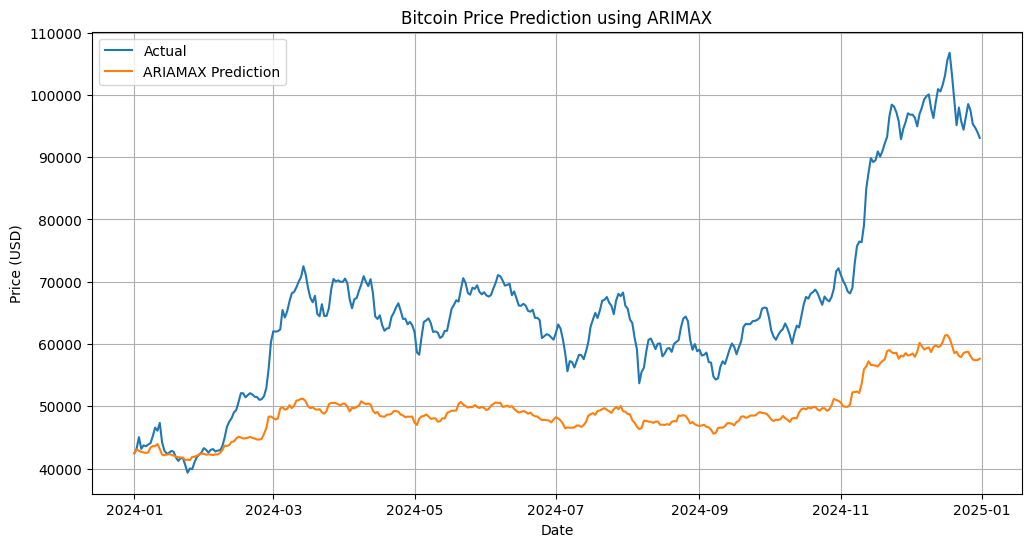

In [ ]:
# Visualisasi langsung tanpa DataFrame
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, actual_arim, label='Actual')
plt.plot(y_test.index, pred_arim, label='ARIAMAX Prediction')
plt.legend()
plt.title('Bitcoin Price Prediction using ARIMAX')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


In [ ]:
# Evaluasi model
mae = mean_absolute_error(actual_arim, pred_arim)
rmse = np.sqrt(mean_squared_error(actual_arim, pred_arim))
mape = np.mean(np.abs((actual_arim - pred_arim) / actual_arim)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 16511.9219
Root Mean Squared Error (RMSE): 19380.7397
Mean Absolute Percentage Error (MAPE): 23.02%


In [ ]:
#========================================================================================

In [ ]:
df_arima = df.copy()
df_arima

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


In [ ]:
# Creating a new feature for better representing day-wise values
df_arima['Mean'] = (df_arima['Low'] + df_arima['High']) / 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Sebelum differencing
result_before = adfuller(df_arima['Close'])
print('Sebelum Differencing:')
print('ADF Statistic:', result_before[0])
print('p-value:', result_before[1])
if result_before[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

# Differencing
df_arima['Close_diff1'] = df_arima['Close'].diff()  # Menghilangkan pola

# Menghapus nilai NaN yang dihasilkan oleh differencing
df_arima.dropna(inplace=True)

# Setelah differencing
result_after = adfuller(df_arima['Close_diff1'])
print('\nSetelah Differencing:')
print('ADF Statistic:', result_after[0])
print('p-value:', result_after[1])
if result_after[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

Sebelum Differencing:
ADF Statistic: 0.0012839333152797835
p-value: 0.9586381377359496
Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)

Setelah Differencing:
ADF Statistic: -8.858429370184508
p-value: 1.5056621117325513e-14
Hasil uji menunjukkan deret waktu stasioner (Tolak H0)


In [ ]:
# Creating a copy for making small changes
dataset_for_prediction = df_arima.copy()
dataset_for_prediction['Actual'] = dataset_for_prediction['Mean'].shift()
dataset_for_prediction = dataset_for_prediction.dropna()

In [ ]:
# 6. Creating Lag Features
lags = [8, 9, 10, 24, 25]
for lag in lags:
    df_arima[f'Close_lag_{lag}'] = df_arima['Close'].shift(lag)
df_arima.dropna(inplace=True)

In [ ]:
df_arima

,Close,High,Low,Open,Volume,Mean,Close_diff1,Close_lag_8,Close_lag_9,Close_lag_10,Close_lag_19,Close_lag_25
Date,,,,,,,,,,,,
2015-01-27,263.475006,275.480011,250.653000,273.166992,4.439900e+07,263.066505,-9.997986,214.860992,210.339004,199.259995,283.348999,315.032013
2015-01-28,233.914993,266.535004,227.046005,263.351013,4.435220e+07,246.790504,-29.560013,211.315002,214.860992,210.339004,290.407989,281.082001
2015-01-29,233.513001,238.705994,220.712006,233.348007,3.221340e+07,229.709000,-0.401993,226.897003,211.315002,214.860992,274.795990,264.195007
2015-01-30,226.425003,242.850998,225.839004,232.772003,2.660520e+07,234.345001,-7.087997,233.406006,226.897003,211.315002,265.660004,274.473999
2015-01-31,217.464004,233.503998,216.309006,226.440994,2.334820e+07,224.906502,-8.960999,232.878998,233.406006,226.897003,267.795990,286.188995
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10,95302.792970,-1630.656250,97490.953130,100041.539100,106140.601600,101236.015600,95865.304690
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10,94770.093750,999.070310,97755.929690,97490.953130,100041.539100,97432.718750,96002.164060
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10,94028.332030,-1633.703130,97224.726560,97755.929690,97490.953130,96675.429690,98768.531250


In [ ]:
# 8. Feature Scaling
sc_in = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(sc_in.fit_transform(dataset_for_prediction[['Low', 'High', 'Open', 'Close', 'Volume','Mean']]),
                 index=dataset_for_prediction.index,
                 columns=['Low', 'High', 'Open', 'Close', 'Volume','Mean'])

sc_out = MinMaxScaler(feature_range=(0, 1))
y = pd.DataFrame(sc_out.fit_transform(dataset_for_prediction[['Actual']]),
                 index=dataset_for_prediction.index,
                 columns=['BTC Price next day'])

In [ ]:
# 9. Selecting Relevant Features
X = df_arima.drop(columns=['Volume', 'Close_diff1','Mean', 'Close', 'High', 'Low'])

y = y.loc['2015-01-27':, 'BTC Price next day']

In [ ]:
# Train-test split (cannot shuffle in case of time series)
train_size = int(len(df_arima[:'2023-11-11']))
test_size = len(df_arima) - train_size
train_X, train_y = X[:train_size].dropna(), y[:train_size].dropna()
test_X, test_y = X[train_size:].dropna(), y[train_size:].dropna()


In [ ]:
# Init the best ARIMAX model
model_arimax = ARIMA(
    train_y,
    exog = train_X,
    order=(1, 1, 1)
)

# Training the model
results_arimax = model_arimax.fit()
print(results_arimax.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:     BTC Price next day   No. Observations:                 3211
Model:                 ARIMA(1, 1, 1)   Log Likelihood               12924.823
Date:                Sun, 20 Jul 2025   AIC                         -25831.645
Time:                        06:21:57   BIC                         -25776.979
Sample:                    01-27-2015   HQIC                        -25812.050
                         - 11-11-2023                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Open          5.166e-06   4.78e-08    107.977      0.000    5.07e-06    5.26e-06
Close_lag_8   3.009e-07   4.12e-08      7.295      0.000     2.2e-07    3.82e-07
Close_lag_9  -3.256e-07   4.54e-08     -7.17

In [ ]:
# Get predictions
predictions = results_arimax.predict(start=train_size, end=train_size + test_size - 1, exog=test_X)

# Setting up for plots
act = pd.DataFrame(y.iloc[train_size:], columns=['BTC Price next day'])
predictions = pd.DataFrame(predictions)
predictions.reset_index(drop=True, inplace=True)
predictions.index = test_X.index
predictions['Actual'] = act.values
predictions.rename(columns={0: 'Pred', 'predicted_mean': 'Pred'}, inplace=True)

# Post-processing: inverting normalization
testPredict = sc_out.inverse_transform(predictions[['Pred']])
testActual = sc_out.inverse_transform(predictions[['Actual']])

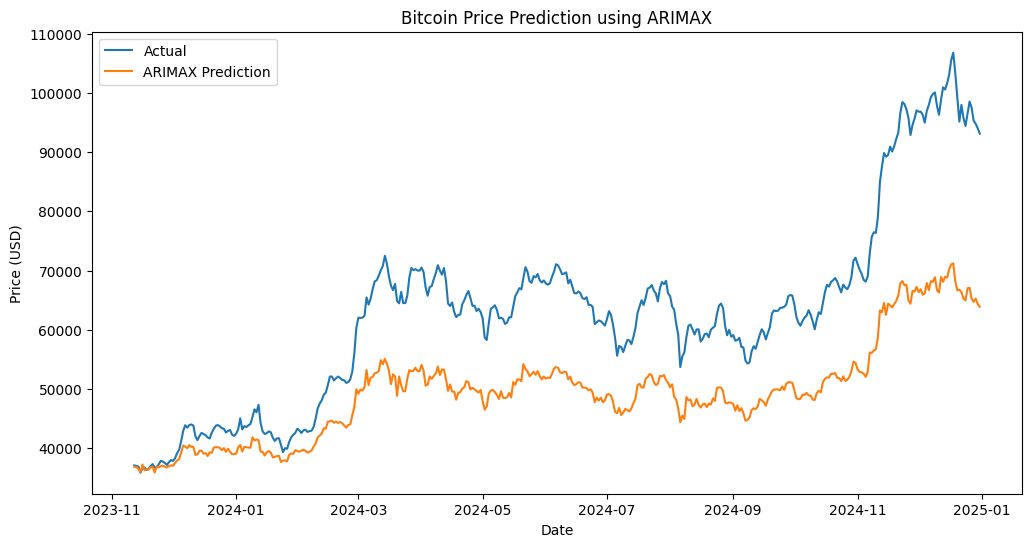

In [ ]:
# Prediction plots
plt.figure(figsize=(12, 6))
plt.plot(predictions.index, testActual, label='Actual')
plt.plot(predictions.index, testPredict, label='ARIMAX Prediction')
plt.legend()
plt.title('Bitcoin Price Prediction using ARIMAX')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Evaluasi model
mae = mean_absolute_error(testActual, testPredict)
rmse = np.sqrt(mean_squared_error(testActual, testPredict))
mape = np.mean(np.abs((testActual - testPredict) / testActual)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 13202.8713
Root Mean Squared Error (RMSE): 15425.6735
Mean Absolute Percentage Error (MAPE): 19.16%


# ARIMAX + Volatilitas (Low, High, Volume)

In [ ]:
df_arim = df.copy()
df_arim

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Sebelum differencing
result_before = adfuller(df_arim['Close'])
print('Sebelum Differencing:')
print('ADF Statistic:', result_before[0])
print('p-value:', result_before[1])
if result_before[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

# Differencing
df_arim['Close_diff1'] = df_arim['Close'].diff()  # Menghilangkan pola

# Menghapus nilai NaN yang dihasilkan oleh differencing
df_arim.dropna(inplace=True)

# Setelah differencing
result_after = adfuller(df_arim['Close_diff1'])
print('\nSetelah Differencing:')
print('ADF Statistic:', result_after[0])
print('p-value:', result_after[1])
if result_after[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

Sebelum Differencing:
ADF Statistic: 0.0012839333152797835
p-value: 0.9586381377359496
Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)

Setelah Differencing:
ADF Statistic: -8.858429370184508
p-value: 1.5056621117325513e-14
Hasil uji menunjukkan deret waktu stasioner (Tolak H0)


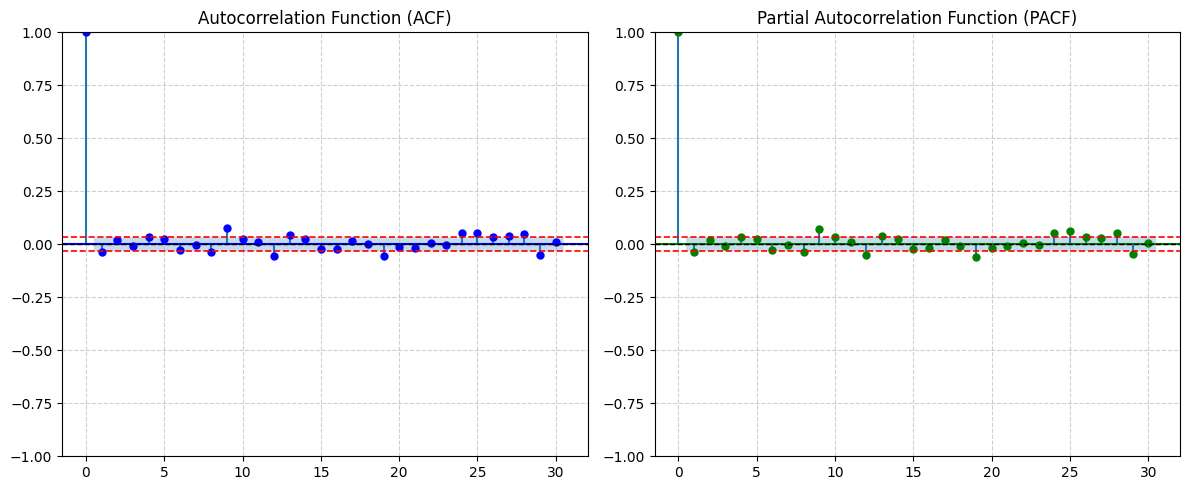

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set level signifikansi
significance_level = 0.05

# Ukuran figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ACF Plot
sm.graphics.tsa.plot_acf(df_arim['Close_diff1'], lags=30, alpha=significance_level, ax=ax1, color='blue')
ax1.axhline(y=0, linestyle='--', color='black', linewidth=1)  # Garis tengah
ax1.axhline(y=1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas atas signifikan
ax1.axhline(y=-1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas bawah signifikan
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_title('Autocorrelation Function (ACF)', fontsize=12)

# PACF Plot
sm.graphics.tsa.plot_pacf(df_arim['Close_diff1'], lags=30, alpha=significance_level, ax=ax2, color='green')
ax2.axhline(y=0, linestyle='--', color='black', linewidth=1)  # Garis tengah
ax2.axhline(y=1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas atas signifikan
ax2.axhline(y=-1.96/np.sqrt(len(df_arim['Close_diff1'])), linestyle='--', color='red', linewidth=1.2)  # Batas bawah signifikan
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_title('Partial Autocorrelation Function (PACF)', fontsize=12)

# Menyesuaikan tata letak
plt.tight_layout()
plt.show()


In [ ]:
# Mean dan fitur lag
df_arim['Mean'] = (df_arim['Low'] + df_arim['High']) / 2
df_arim['Actual'] = df_arim['Mean'].shift()


In [ ]:
# Fitur dan target
feature_cols = ['Low', 'High', 'Volume']
X_raw = df_arim[feature_cols]
y_raw = df_arim[['Actual']]


In [ ]:
# Scaling
sc_X = MinMaxScaler()
sc_y = MinMaxScaler()
X_scaled = pd.DataFrame(sc_X.fit_transform(X_raw), index=X_raw.index, columns=feature_cols)
y_scaled = pd.DataFrame(sc_y.fit_transform(y_raw), index=y_raw.index, columns=['BTC Price next day'])


In [ ]:
# Split train-test
# train_end = '2023-12-31'
train_end = '2024-01-01'
X_train = X_scaled[:train_end]
X_test = X_scaled[train_end:]
y_train = y_scaled[:train_end]
y_test = y_scaled[train_end:]


In [ ]:
# ARIMA dengan exogenous
model_arim = ARIMA(y_train, exog=X_train, order=(1, 1, 0))
results_arim = model_arim.fit()
print(results_arim.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:     BTC Price next day   No. Observations:                 3287
Model:                 ARIMA(1, 1, 0)   Log Likelihood               12310.361
Date:                Wed, 23 Jul 2025   AIC                         -24610.723
Time:                        08:37:11   BIC                         -24580.236
Sample:                    01-02-2015   HQIC                        -24599.807
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Low            0.0560      0.006      8.765      0.000       0.043       0.069
High           0.2389      0.007     34.464      0.000       0.225       0.253
Volume         0.0214      0.002      9.851      0.0

In [ ]:
# Prediksi ARIMA
pred_scaled = results_arim.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog=X_test)
pred_arim = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
actual_arim = sc_y.inverse_transform(y_test.values)


## Visualisasi

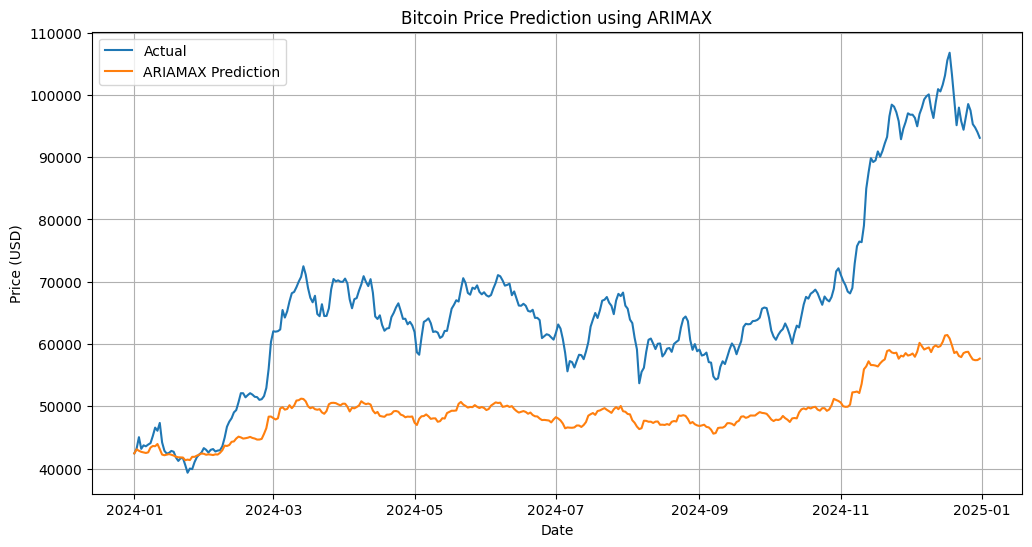

In [ ]:
# Visualisasi langsung tanpa DataFrame
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, actual_arim, label='Actual')
plt.plot(y_test.index, pred_arim, label='ARIAMAX Prediction')
plt.legend()
plt.title('Bitcoin Price Prediction using ARIMAX')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


In [ ]:
# Evaluasi model
mae = mean_absolute_error(actual_arim, pred_arim)
rmse = np.sqrt(mean_squared_error(actual_arim, pred_arim))
mape = np.mean(np.abs((actual_arim - pred_arim) / actual_arim)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 16511.9307
Root Mean Squared Error (RMSE): 19380.7501
Mean Absolute Percentage Error (MAPE): 23.02%


# LSTM

In [ ]:
import random
import tensorflow as tf

# Set seed agar hasil tidak berubah-ubah
seed_value = 57
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [ ]:
df_baru = df.copy()
df_baru

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


In [ ]:
# # Pisahkan train dan test berdasarkan tanggal
# train_data = df_baru.loc['2015-01-01':'2023-11-11', ['Close' ,'Close_lag_8', 'Close_lag_9', 'Close_lag_10', 'Close_lag_24', 'Close_lag_25']].values
# test_data = df_baru.loc['2023-11-12':'2024-12-31', ['Close' ,'Close_lag_8', 'Close_lag_9', 'Close_lag_10', 'Close_lag_24', 'Close_lag_25']].values


In [ ]:
# Pisahkan train dan test berdasarkan tanggal
train_data = df_baru.loc['2015-01-01':'2023-11-11', ['High', 'Low', 'Volume']].values
test_data = df_baru.loc['2023-11-12':'2024-12-31', ['High', 'Low', 'Volume']].values


In [ ]:
test_data.shape

(416, 3)

In [ ]:
# Normalisasi data
scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)


In [ ]:
# Fungsi untuk membuat sequence
def create_sequences(data_sec, seq_length):
    sequences, labels = [], []
    for i in range(len(data_sec) - seq_length):
        sequences.append(data_sec[i:i+seq_length])
        labels.append(data_sec[i+seq_length, 0])  # Variabel target (y) adalah nilai berikutnya dari 'Close'
    return np.array(sequences), np.array(labels)


In [ ]:
# Tentukan panjang sequence
seq_length = 50  # Panjang sequence input ke LSTM

In [ ]:
# Buat sequence untuk training dan testing
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)


In [ ]:
# Membangun model LSTM
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 3)),  # 5 fitur lag
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Melatih model
model_lstm.fit(X_train, y_train, epochs=10, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - loss: 0.0480 - val_loss: 0.0973
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0064 - val_loss: 0.0655
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - loss: 0.0053 - val_loss: 0.0414
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 0.0048 - val_loss: 0.0151
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 0.0045 - val_loss: 0.0157
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0038 - val_loss: 0.0147
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0032 - val_loss: 0.0219
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - loss: 0.0039 - val_loss: 0.0232
Epoch 9/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0033 - val_loss: 0.0471
Epoch 10/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - loss: 0.0035 - val_loss: 0.0131


In [ ]:
# Melakukan prediksi
y_pred = model_lstm.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [ ]:
y_pred.shape

(366, 1)

In [ ]:
# Inverse transform hanya pada kolom target (prediksi harga)
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((y_pred.shape[0], 2))), axis=1))[:, 0]

# Inverse transform pada data uji
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 2))), axis=1))[:, 0]


## Visualisasi LSTM

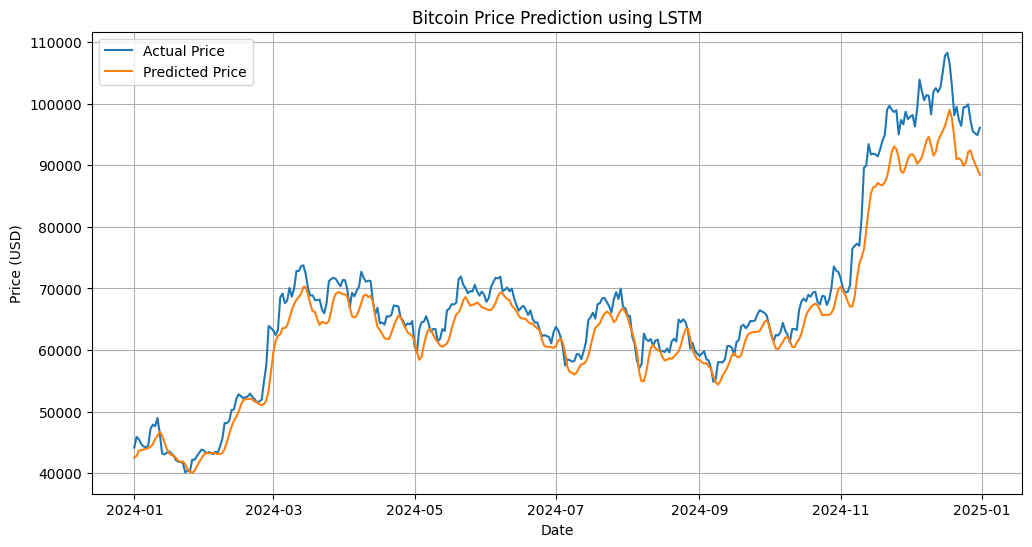

In [ ]:
test_index = df_baru.loc['2023-11-12':'2024-12-31'].index[seq_length:]

# Plot hasil prediksi
plt.figure(figsize=(12,6))
plt.plot(test_index ,y_test_rescaled, label='Actual Price')
plt.plot(test_index ,y_pred_rescaled, label='Predicted Price')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Bitcoin Price Prediction using LSTM')
plt.grid(True)
plt.show()

In [ ]:
# Evaluasi model
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 2949.0709
Root Mean Squared Error (RMSE): 3925.3468
Mean Absolute Percentage Error (MAPE): 4.03%


# Hybrid Model

## **1. Hybrid ARIMA - LSTM (residual ARIMA baru) 2x pembagian**

In [ ]:
data_baru = df["Close"].copy()
data_baru

,Close
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999
...,...
2024-12-27,94164.859380
2024-12-28,95163.929690
2024-12-29,93530.226560


In [ ]:
# ARIMA Modeling
# Train ARIMA dari 2015-01-01 sampai 2020-12-31

train_arima = data_baru.loc['2015-01-01':'2019-12-31']

In [ ]:
# Fit ARIMA model
arima_model = ARIMA(train_arima, order=(1,1,0))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1826
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -12915.081
Date:                Wed, 23 Jul 2025   AIC                          25834.162
Time:                        08:35:37   BIC                          25845.180
Sample:                    01-01-2015   HQIC                         25838.226
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0408      0.007      5.687      0.000       0.027       0.055
sigma2      8.214e+04    771.339    106.490      0.000    8.06e+04    8.37e+04
Ljung-Box (L1) (Q):                   0.00   Jarque-

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# Predict pakai ARIMA untuk periode 2020-01-01 sampai 2024-12-31
arima_pred = arima_result.predict(start='2020-01-01', end='2024-12-31', typ='levels')


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


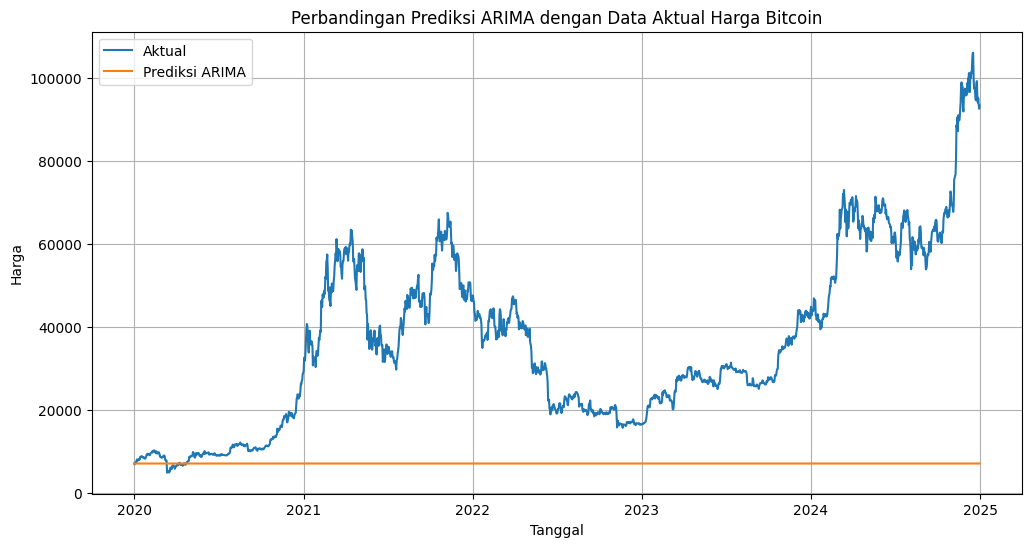

In [ ]:
# Plot hasil prediksi ARIMA vs data aktual
plt.figure(figsize=(12, 6))
plt.plot(data_baru.loc['2020-01-01':'2024-12-31'], label='Aktual')
plt.plot(arima_pred.loc['2020-01-01':'2024-12-31'], label='Prediksi ARIMA')
plt.title('Perbandingan Prediksi ARIMA dengan Data Aktual Harga Bitcoin')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Hitung residual: actual - ARIMA prediction
# Data aktual dari 2020-01-01 sampai 2024-12-31
actual_data_for_residual = data_baru.loc['2020-01-01':'2024-12-31']
residual = actual_data_for_residual - arima_pred


In [ ]:
# # Plot residual
# plt.figure(figsize=(12, 6))
# plt.plot(residual, label='Residuals', color='red')
# plt.title('Residual Plot of ARIMA Model')
# plt.xlabel('Date')
# plt.ylabel('Residual Value')
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
# Pisahkan Train dan Test untuk Hybrid (Residual Modeling)
# Train Hybrid (LSTM) residual: 2020-01-01 sampai 2023-11-11
train_residual = residual.loc['2020-01-01':'2023-11-11'].values.reshape(-1,1)


In [ ]:
# Test Hybrid (LSTM) residual: 2023-11-12 sampai 2024-12-31
test_residual = residual.loc['2023-11-12':'2024-12-31'].values.reshape(-1,1)


### Residual Plot

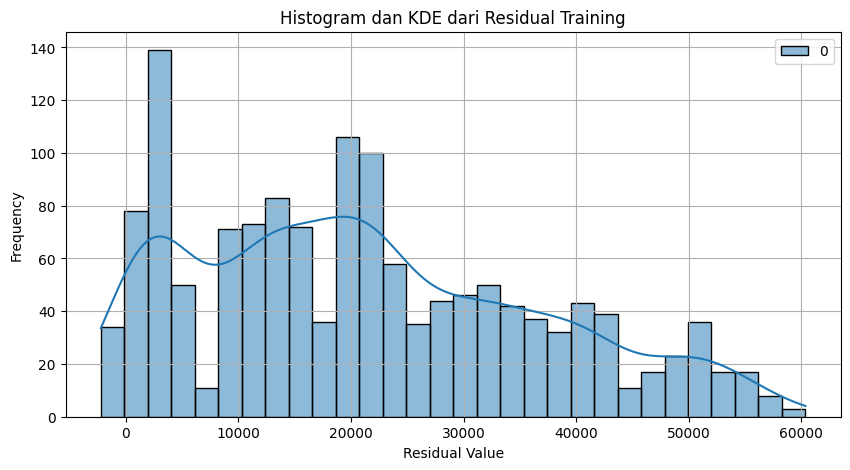

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(train_residual, kde=True, bins=30, color='skyblue')
plt.title('Histogram dan KDE dari Residual Training')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


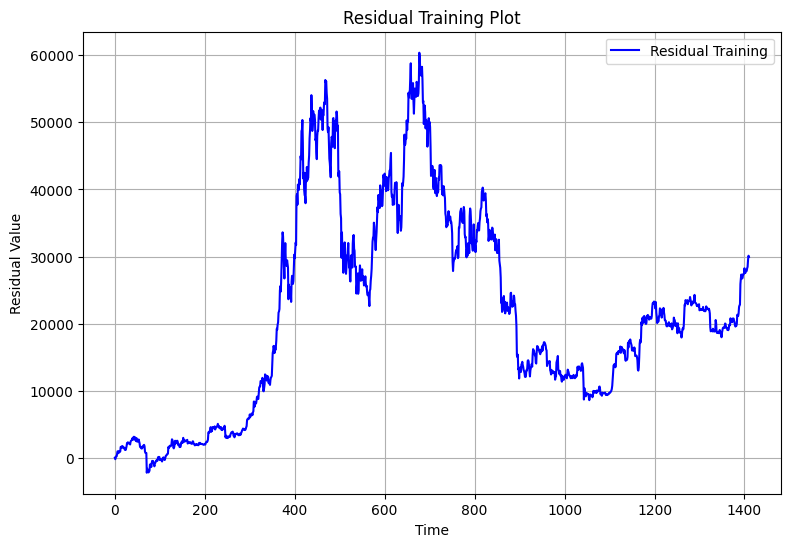

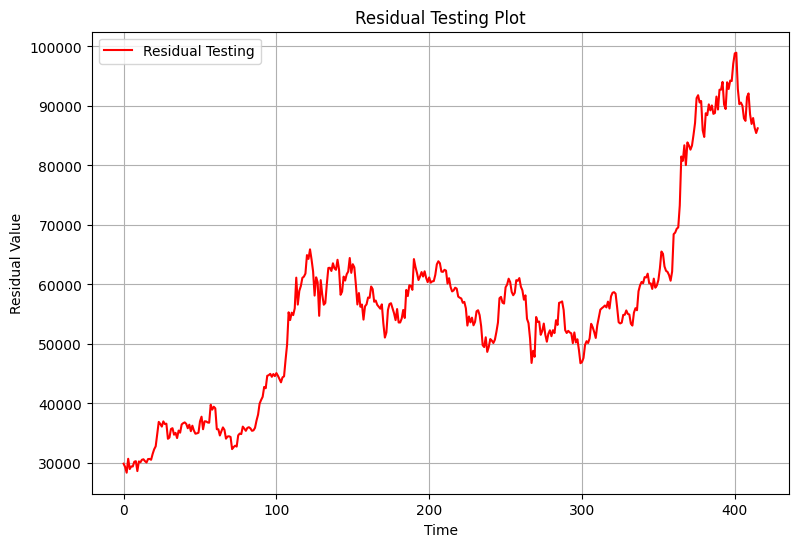

In [ ]:
import matplotlib.pyplot as plt

# Plot residual training
plt.figure(figsize=(9, 6))
plt.plot(train_residual, label='Residual Training', color='blue')
plt.title('Residual Training Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot residual testing
plt.figure(figsize=(9, 6))
plt.plot(test_residual, label='Residual Testing', color='red')
plt.title('Residual Testing Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Scaling residual
scaler = MinMaxScaler(feature_range=(-1, 1))
train_residual_scaled = scaler.fit_transform(train_residual)
test_residual_scaled = scaler.transform(test_residual)

In [ ]:
# Fungsi untuk membuat sequence
def create_sequences(data_sec, seq_length):
    sequences, labels = [], []
    for i in range(len(data_sec) - seq_length):
        sequences.append(data_sec[i:i+seq_length])
        labels.append(data_sec[i+seq_length, 0])
    return np.array(sequences), np.array(labels)

In [ ]:
# Buat sequences
seq_length = 50

In [ ]:
X_train, y_train = create_sequences(train_residual_scaled, seq_length)
X_test, y_test = create_sequences(test_residual_scaled, seq_length)

In [ ]:
# Reshape untuk input ke LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
# Build dan train LSTM
model_lstm_utama = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_lstm_utama.compile(optimizer='adam', loss='mean_squared_error')

model_lstm_utama.fit(X_train, y_train, epochs=10, batch_size=8, verbose=1)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


171/171 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - loss: 0.0396
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 0.0090
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0072
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0063
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0074
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.0053
Epoch 7/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.0047
Epoch 8/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0056
Epoch 9/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 0.0047
Epoch 10/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0041


In [ ]:
# Predict residual menggunakan LSTM
lstm_pred = model_lstm_utama.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


In [ ]:
# prediction (ARIMA prediction + LSTM residual correction)
# Ambil ARIMA prediction dari 2023-11-12 sampai 2024-12-31
arima_pred_for_hybrid = arima_pred.loc['2023-11-12':'2024-12-31'].values

In [ ]:
# Karena kita pakai sequence (50), ARIMA prediction harus dipotong juga
arima_pred_for_hybrid = arima_pred_for_hybrid[seq_length:]

In [ ]:
# Hybrid prediction
final_pred = arima_pred_for_hybrid + lstm_pred.flatten()

In [ ]:
# Plot hasil
true = data_baru.loc['2023-11-12':'2024-12-31']
true = true[seq_length:]

### Visualisasi Hybrid



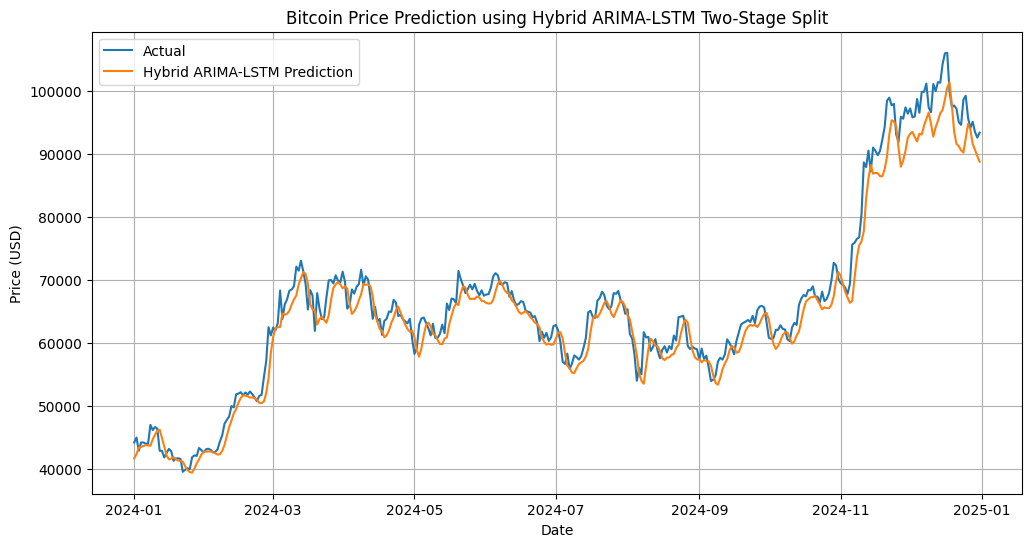

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(true.index, true.values, label='Actual')
plt.plot(true.index, final_pred, label='Hybrid ARIMA-LSTM Prediction')
plt.legend()
plt.title('Bitcoin Price Prediction using Hybrid ARIMA-LSTM Two-Stage Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid()
plt.show()

In [ ]:
# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_hybrid = mean_absolute_error(true.values, final_pred)
rmse_hybrid = np.sqrt(mean_squared_error(true.values, final_pred))
mape_hybrid = np.mean(np.abs((true.values - final_pred) / true.values)) * 100

print(f"Hybrid Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_hybrid:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_hybrid:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_hybrid:.2f}%")

Hybrid Model Evaluation:
Mean Absolute Error (MAE): 2154.6256
Root Mean Squared Error (RMSE): 2859.1245
Mean Absolute Percentage Error (MAPE): 3.12%


## **2. Hybrid ARIMAX - LSTM (residual ARIMAX) 2x pembagian**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
#  Copy data dan differencing
df_arimax = df.copy()
df_arimax['Close_diff1'] = df_arimax['Close'].diff()
df_arimax.dropna(inplace=True)

In [ ]:
#  Cek stasioneritas
result = adfuller(df_arimax['Close_diff1'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] <= 0.05:
    print("Data stasioner (Tolak H0)")
else:
    print("Data tidak stasioner (Gagal Tolak H0)")


ADF Statistic: -8.858429370184508
p-value: 1.5056621117325513e-14
Data stasioner (Tolak H0)


In [ ]:
# Tambahkan fitur rata-rata harga (Mean)
df_arimax['Mean'] = (df_arimax['Low'] + df_arimax['High']) / 2

In [ ]:
#  Tambahkan target 'Actual' sebagai target harga besok
df_arimax['Actual'] = df_arimax['Mean'].shift(-1)
df_arimax.dropna(inplace=True)

In [ ]:
df_arimax

,Close,High,Low,Open,Volume,Close_diff1,Mean,Actual
Date,,,,,,,,
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06,0.783020,314.701996,298.115997
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07,-33.950012,298.115997,272.421005
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07,-16.886993,272.421005,271.712509
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07,10.278992,271.712509,280.124512
2015-01-06,286.188995,287.553009,272.696014,274.610992,2.324570e+07,11.714996,280.124512,290.916504
...,...,...,...,...,...,...,...,...
2024-12-26,95795.515630,99884.570310,95137.882810,99297.695310,4.705498e+10,-3503.679680,97511.226560,95302.792970
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10,-1630.656250,95302.792970,94770.093750
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10,999.070310,94770.093750,94028.332030


In [ ]:
#  Definisikan fitur dan target
feature_cols = ['High', 'Low', 'Volume']
target_col = 'Actual'


In [ ]:
X_raw = df_arimax[feature_cols]
y_raw = df_arimax[[target_col]]

In [ ]:
#  Scaling data
sc_X = MinMaxScaler()
sc_y = MinMaxScaler()

In [ ]:
X_scaled = pd.DataFrame(sc_X.fit_transform(X_raw), index=X_raw.index, columns=X_raw.columns)
y_scaled = pd.DataFrame(sc_y.fit_transform(y_raw), index=y_raw.index, columns=['BTC Price next day'])

In [ ]:
#  Split train-test berdasarkan waktu
train_end = '2019-12-31'
X_train = X_scaled[:train_end]
X_test = X_scaled[train_end:]
y_train = y_scaled[:train_end]
y_test = y_scaled[train_end:]

In [ ]:
#  Fit ARIMAX model
model = ARIMA(y_train, exog=X_train, order=(1,1,0))
results = model.fit()
print(results.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:     BTC Price next day   No. Observations:                 1825
Model:                 ARIMA(1, 1, 0)   Log Likelihood                8631.775
Date:                Wed, 23 Jul 2025   AIC                         -17253.550
Time:                        08:40:34   BIC                         -17226.006
Sample:                    01-02-2015   HQIC                        -17243.390
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
High           0.1403      0.015      9.541      0.000       0.111       0.169
Low            0.1293      0.017      7.652      0.000       0.096       0.162
Volume         0.0227      0.005      4.761      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
#  Predict using test set
pred_scaled = results.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)


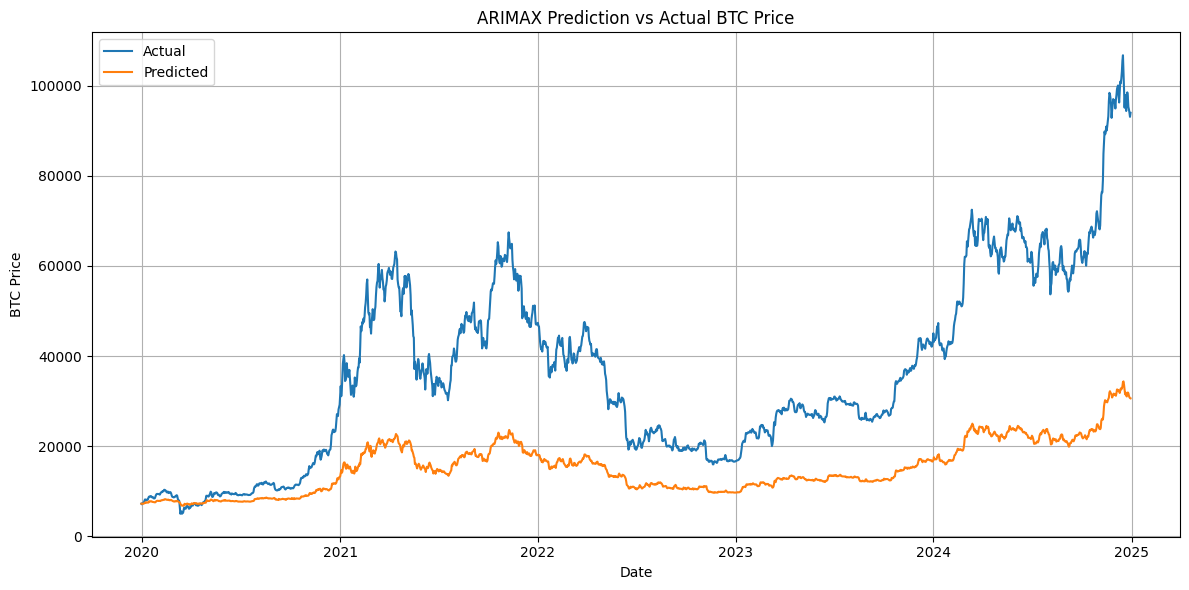

In [ ]:
# Inversi skala hasil prediksi dan actual
pred = sc_y.inverse_transform(pred_scaled.values.reshape(-1, 1))
actual = sc_y.inverse_transform(y_test.values)

#  Plot hasil prediksi vs aktual
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, actual, label='Actual')
plt.plot(y_test.index, pred, label='Predicted')
plt.title('ARIMAX Prediction vs Actual BTC Price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
#  Evaluasi hasil
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
mape = np.mean(np.abs((actual - pred) / actual)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 21182.3952
Root Mean Squared Error (RMSE): 26146.3393
Mean Absolute Percentage Error (MAPE): 50.66%


In [ ]:
# Pastikan testActual dan testPredict berasal dari ARIMAX
residual = actual - pred  # bentuknya sudah 2D

In [ ]:
# Buat index time series-nya jika hilang
residual = pd.DataFrame(residual, index=pred_scaled.index, columns=["residual"])


In [ ]:
# Split Residual untuk LSTM
residual.index = pd.to_datetime(residual.index)
train_residual = residual.loc['2020-01-01':'2023-11-11'].values.reshape(-1,1)
test_residual = residual.loc['2023-11-12':'2024-12-31'].values.reshape(-1,1)

### Residual Plot

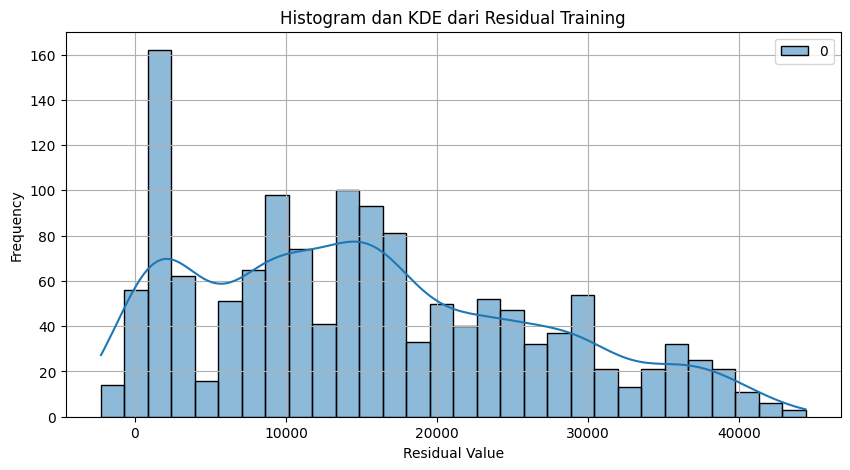

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(train_residual, kde=True, bins=30, color='skyblue')
plt.title('Histogram dan KDE dari Residual Training')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


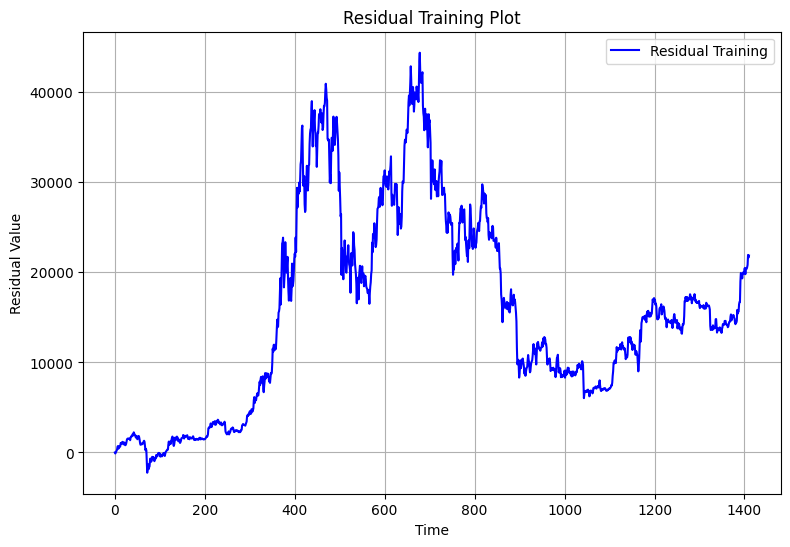

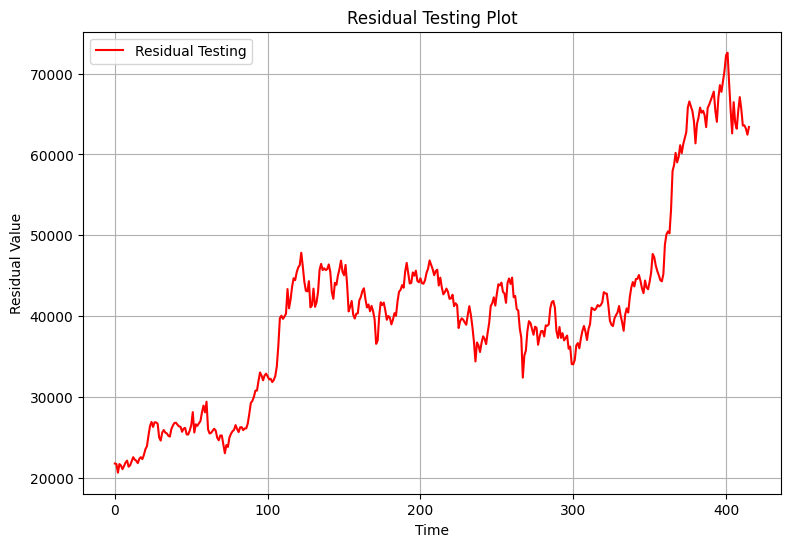

In [ ]:
import matplotlib.pyplot as plt

# Plot residual training
plt.figure(figsize=(9, 6))
plt.plot(train_residual, label='Residual Training', color='blue')
plt.title('Residual Training Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot residual testing
plt.figure(figsize=(9, 6))
plt.plot(test_residual, label='Residual Testing', color='red')
plt.title('Residual Testing Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#  Scaling Residual
sc_res = MinMaxScaler(feature_range=(-1, 1))
train_residual_scaled = sc_res.fit_transform(train_residual)
test_residual_scaled = sc_res.transform(test_residual)

In [ ]:
#  Sequence Function
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

seq_len = 50
X_train, y_train = create_sequences(train_residual_scaled, seq_len)
X_test, y_test = create_sequences(test_residual_scaled, seq_len)


In [ ]:
#  Reshape untuk LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [ ]:
#  Build LSTM
model_lstm1 = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_len, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_lstm1.compile(optimizer='adam', loss='mean_squared_error')
model_lstm1.fit(X_train, y_train, epochs=10, batch_size=8, verbose=1)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


171/171 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - loss: 0.0267
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0079
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 0.0069
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0066
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.0057
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 0.0057
Epoch 7/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0052
Epoch 8/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0060
Epoch 9/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0053
Epoch 10/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 0.0056


In [ ]:
#  Predict Residual
lstm_pred2 = model_lstm1.predict(X_test)
lstm_pred2 = sc_res.inverse_transform(lstm_pred2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [ ]:
#  Gabungkan dengan ARIMAX
# Potong prediksi ARIMAX agar sejajar dengan prediksi LSTM
arimax_cut = pred[-len(lstm_pred2):]
final_hybrid_pred = arimax_cut.flatten() + lstm_pred2.flatten()

### Visualisasi Hybrid

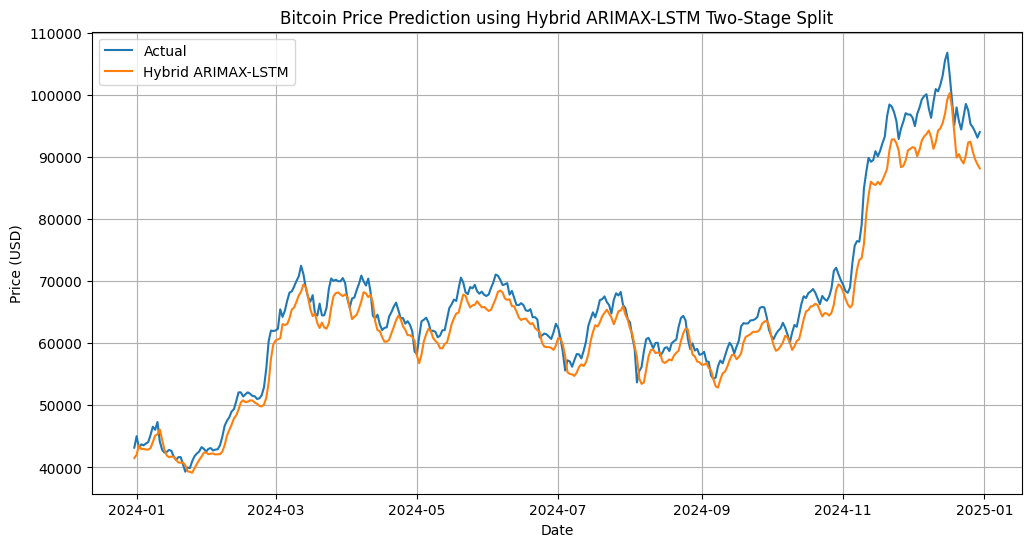

In [ ]:
test_index_2 = df_arimax.loc['2023-11-11':'2024-12-31'].index[seq_length:]

# --- 10. Plot Hasil Hybrid ---
true_cut = actual[-len(lstm_pred2):]

plt.figure(figsize=(12,6))
plt.plot(test_index_2, true_cut, label='Actual')
plt.plot(test_index_2, final_hybrid_pred, label='Hybrid ARIMAX-LSTM')
plt.title('Bitcoin Price Prediction using Hybrid ARIMAX-LSTM Two-Stage Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_hybrid = mean_absolute_error(true_cut, final_hybrid_pred)
rmse_hybrid = np.sqrt(mean_squared_error(true_cut, final_hybrid_pred))
mape_hybrid = np.mean(np.abs((true_cut - final_hybrid_pred) / true_cut)) * 100

print(f"Hybrid Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_hybrid:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_hybrid:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_hybrid:.2f}%")

Hybrid Model Evaluation:
Mean Absolute Error (MAE): 2601.1836
Root Mean Squared Error (RMSE): 3191.7289
Mean Absolute Percentage Error (MAPE): 22.77%


## **3. ARIMAX-LSTM (VOL) 1**

In [ ]:
df_arimax2 = df.copy()
df_arimax2

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


In [ ]:
# Creating a new feature for better representing day-wise values
df_arimax2['Mean'] = (df_arimax2['Low'] + df_arimax2['High']) / 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Sebelum differencing
result_before = adfuller(df_arimax2['Close'])
print('Sebelum Differencing:')
print('ADF Statistic:', result_before[0])
print('p-value:', result_before[1])
if result_before[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

# Differencing
df_arimax2['Close_diff1'] = df_arimax2['Close'].diff()  # Menghilangkan pola

# Menghapus nilai NaN yang dihasilkan oleh differencing
df_arimax2.dropna(inplace=True)

# Setelah differencing
result_after = adfuller(df_arimax2['Close_diff1'])
print('\nSetelah Differencing:')
print('ADF Statistic:', result_after[0])
print('p-value:', result_after[1])
if result_after[1] <= 0.05:
    print("Hasil uji menunjukkan deret waktu stasioner (Tolak H0)")
else:
    print("Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)")

Sebelum Differencing:
ADF Statistic: 0.0012839333152797835
p-value: 0.9586381377359496
Hasil uji menunjukkan deret waktu tidak stasioner (Gagal tolak H0)

Setelah Differencing:
ADF Statistic: -8.858429370184508
p-value: 1.5056621117325513e-14
Hasil uji menunjukkan deret waktu stasioner (Tolak H0)


In [ ]:
# Creating a copy for making small changes
dataset_for_prediction2 = df_arimax2.copy()
df_arimax2 = df_arimax2.loc['2015-01-03':]
dataset_for_prediction2['Actual'] = dataset_for_prediction2['Mean'].shift()
dataset_for_prediction2 = dataset_for_prediction2.dropna()

In [ ]:
dataset_for_prediction2

,Close,High,Low,Open,Volume,Mean,Close_diff1,Actual
Date,,,,,,,,
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07,298.115997,-33.950012,314.701996
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07,272.421005,-16.886993,298.115997
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07,271.712509,10.278992,272.421005
2015-01-06,286.188995,287.553009,272.696014,274.610992,2.324570e+07,280.124512,11.714996,271.712509
2015-01-07,294.337006,298.753998,283.079010,286.076996,2.486680e+07,290.916504,8.148010,280.124512
...,...,...,...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10,95302.792970,-1630.656250,97511.226560
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10,94770.093750,999.070310,95302.792970
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10,94028.332030,-1633.703130,94770.093750


In [ ]:
# Feature Scaling
sc_in = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(sc_in.fit_transform(dataset_for_prediction2[['Low', 'High', 'Open', 'Close', 'Volume','Mean']]),
                 index=dataset_for_prediction2.index,
                 columns=['Low', 'High', 'Open', 'Close', 'Volume','Mean'])

sc_out = MinMaxScaler(feature_range=(0, 1))
y = pd.DataFrame(sc_out.fit_transform(dataset_for_prediction2[['Actual']]),
                 index=dataset_for_prediction2.index,
                 columns=['BTC Price next day'])

In [ ]:
# Selecting Relevant Features
X = X.drop(columns=['Mean', 'Close', 'Open'])

y = y.loc['2015-01-03':, 'BTC Price next day']

In [ ]:
# Train-test split (cannot shuffle in case of time series)
train_size = int(len(df_arimax2[:'2023-11-11']))
test_size = len(df_arimax2) - train_size
train_X, train_y = X[:train_size].dropna(), y[:train_size].dropna()
test_X, test_y = X[train_size:].dropna(), y[train_size:].dropna()


In [ ]:
# Init the best ARIMAX model
model_arimaxx2 = ARIMA(
    train_y,
    exog = train_X,
    order=(1, 1, 0)
)

# Training the model
results_arimaxx2 = model_arimaxx2.fit()
print(results_arimaxx2.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:     BTC Price next day   No. Observations:                 3235
Model:                 ARIMA(1, 1, 0)   Log Likelihood               12125.393
Date:                Wed, 23 Jul 2025   AIC                         -24240.785
Time:                        08:42:01   BIC                         -24210.378
Sample:                    01-03-2015   HQIC                        -24229.889
                         - 11-11-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Low            0.0520      0.006      8.119      0.000       0.039       0.065
High           0.2420      0.007     34.755      0.000       0.228       0.256
Volume         0.0213      0.002      9.781      0.0

In [ ]:
# Get predictions
predictions = results_arimaxx2.predict(start=train_size, end=train_size + test_size - 1, exog=test_X)

# Setting up for plots
act = pd.DataFrame(y.iloc[train_size:], columns=['BTC Price next day'])
predictions = pd.DataFrame(predictions)
predictions.reset_index(drop=True, inplace=True)
predictions.index = test_X.index
predictions['Actual'] = act.values
predictions.rename(columns={0: 'Pred', 'predicted_mean': 'Pred'}, inplace=True)

# Post-processing: inverting normalization
testPredict = sc_out.inverse_transform(predictions[['Pred']])
testActual = sc_out.inverse_transform(predictions[['Actual']])

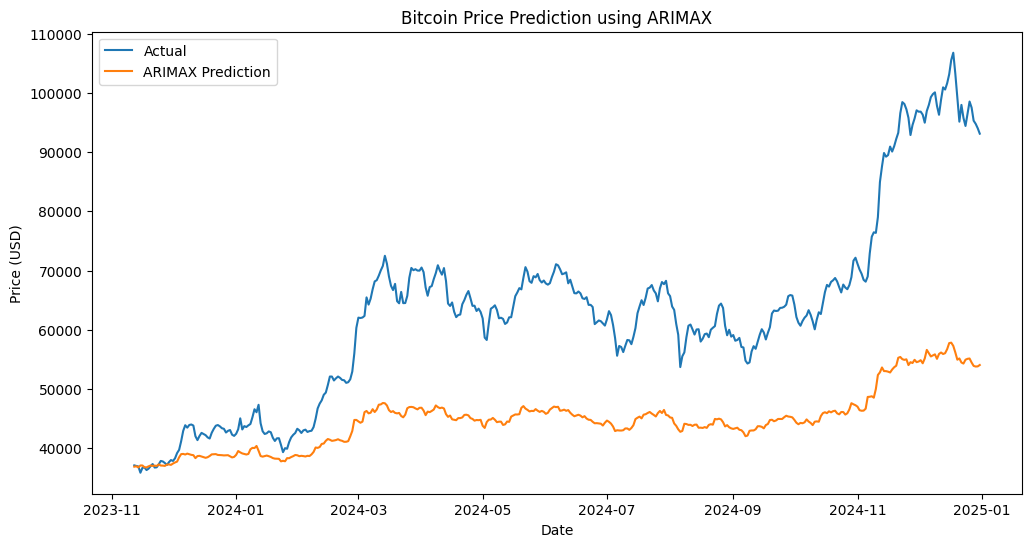

In [ ]:
# Prediction plots
plt.figure(figsize=(12, 6))
plt.plot(predictions.index, testActual, label='Actual')
plt.plot(predictions.index, testPredict, label='ARIMAX Prediction')
plt.legend()
plt.title('Bitcoin Price Prediction using ARIMAX')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


In [ ]:
# Prediksi pada data training
train_pred = results_arimaxx2.predict(start=0, end=train_size-1)
train_actual = train_y.copy()

# Kembalikan ke bentuk aslinya (unscaled)
train_pred_inv = sc_out.inverse_transform(train_pred.values.reshape(-1, 1))
train_actual_inv = sc_out.inverse_transform(train_actual.values.reshape(-1, 1))


In [ ]:
# Residual training
residual_train = train_actual_inv - train_pred_inv

# Residual testing
residual_test = testActual - testPredict


### Residual Plot

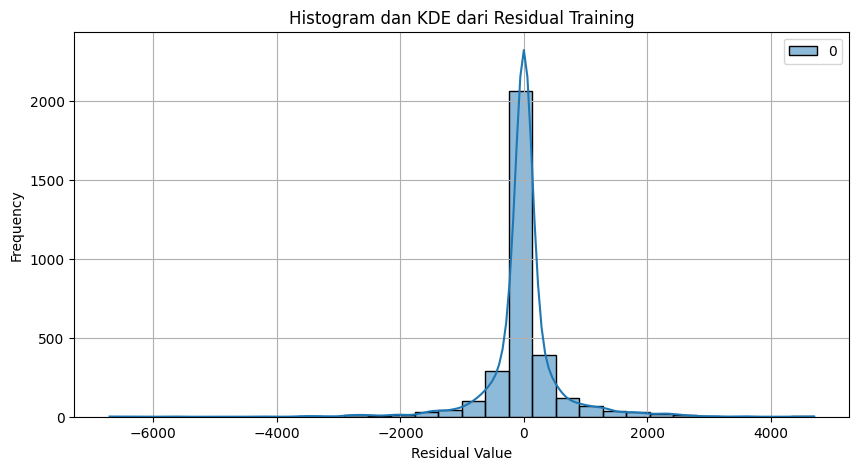

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(residual_train, kde=True, bins=30, color='skyblue')
plt.title('Histogram dan KDE dari Residual Training')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


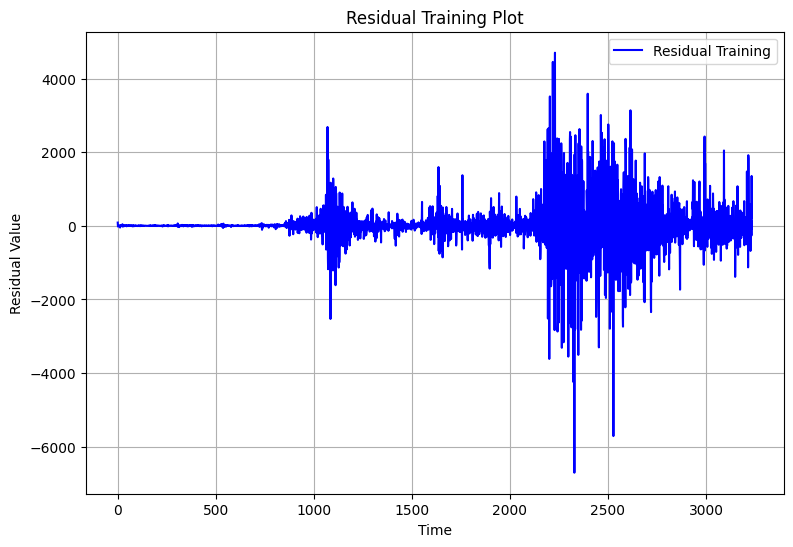

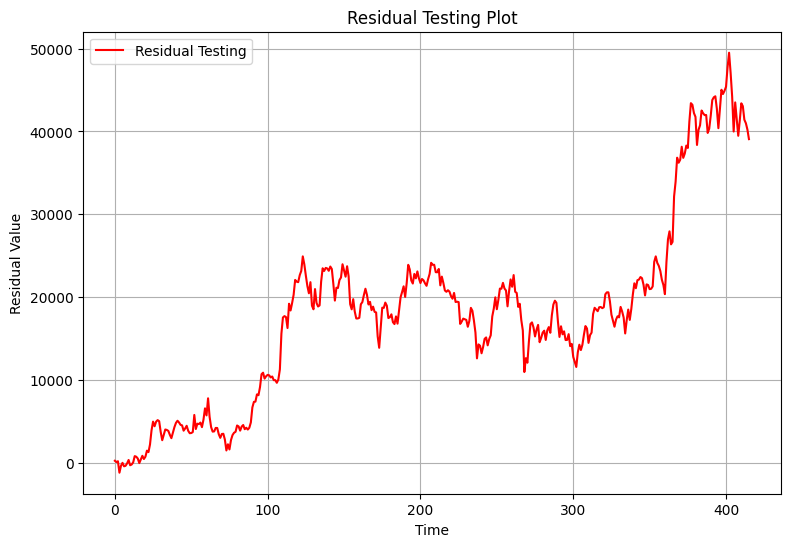

In [ ]:
import matplotlib.pyplot as plt

# Plot residual training
plt.figure(figsize=(9, 6))
plt.plot(residual_train, label='Residual Training', color='blue')
plt.title('Residual Training Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot residual testing
plt.figure(figsize=(9, 6))
plt.plot(residual_test, label='Residual Testing', color='red')
plt.title('Residual Testing Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# Gabungkan residual training dan testing untuk normalisasi
all_residual = np.concatenate((residual_train, residual_test), axis=0)

# Normalisasi residual
sc_resid = MinMaxScaler()
resid_scaled = sc_resid.fit_transform(all_residual)

# Pisahkan kembali
resid_train_scaled = resid_scaled[:len(residual_train)]
resid_test_scaled = resid_scaled[len(residual_train):]


In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)


In [ ]:
seq_length = 50

X_train_lstm, y_train_lstm = create_sequences(resid_train_scaled, seq_length)
X_test_lstm, y_test_lstm = create_sequences(resid_test_scaled, seq_length)

# Reshape untuk LSTM: [samples, time_steps, features]
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Membangun model LSTM
model_lstm4 = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_lstm4.compile(optimizer='adam', loss='mean_squared_error')
model_lstm4.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=8, validation_split=0.2)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


319/319 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - loss: 6.6401e-04 - val_loss: 1.2902e-04
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - loss: 1.3299e-04 - val_loss: 1.2378e-04
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 1.2652e-04 - val_loss: 1.3206e-04
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 1.2532e-04 - val_loss: 1.2901e-04
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - loss: 1.2331e-04 - val_loss: 1.2862e-04
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 1.2399e-04 - val_loss: 1.2994e-04
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - loss: 1.2265e-04 - val_loss: 1.2779e-04
Epoch 8/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - loss: 1.2210e-04 - val_loss: 1.2786e-04
Epoch 9/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - loss: 1.2183e-04 - val_loss: 1.2857e-04
Epoch 10/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 1.2152e-04 - val_loss: 1.2858e-04


In [ ]:
# Prediksi residual dari LSTM
y_pred_lstm1 = model_lstm4.predict(X_test_lstm)

# Invers skala residual
y_pred_lstm_inv = sc_resid.inverse_transform(y_pred_lstm1)

# Pangkas prediksi ARIMA agar panjangnya sama
testPredict_trimmed = testPredict[seq_length:]

# Gabungkan ARIMA + LSTM
y_pred_hybrid = testPredict[50:] + y_pred_lstm_inv

# Bandingkan dengan nilai aktual (juga harus dipangkas)
testActual_trimmed = testActual[seq_length:]

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


### Visualisasi

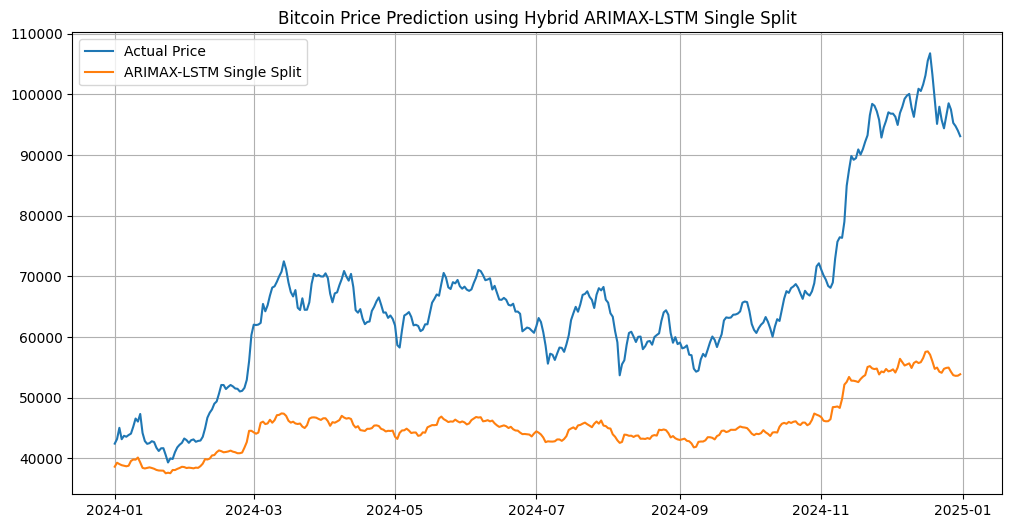

In [ ]:
# Plot hasil hybrid
plt.figure(figsize=(12, 6))
plt.plot(true.index, testActual_trimmed, label='Actual Price')
plt.plot(true.index, y_pred_hybrid, label='ARIMAX-LSTM Single Split')
plt.legend()
plt.title('Bitcoin Price Prediction using Hybrid ARIMAX-LSTM Single Split')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluasi hasil prediksi Hybrid
hybrid_mae = mean_absolute_error(testActual_trimmed, y_pred_hybrid)
hybrid_rmse = np.sqrt(mean_squared_error(testActual_trimmed, y_pred_hybrid))
hybrid_mape = np.mean(np.abs((testActual_trimmed - y_pred_hybrid) / testActual_trimmed)) * 100

print("Evaluation Metrics for Hybrid ARIMA-LSTM Model:")
print(f"Mean Absolute Error (MAE): {hybrid_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {hybrid_rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {hybrid_mape:.2f}%")


Evaluation Metrics for Hybrid ARIMA-LSTM Model:
Mean Absolute Error (MAE): 20261.0653
Root Mean Squared Error (RMSE): 22693.1085
Mean Absolute Percentage Error (MAPE): 28.96%


## **4. Hybrid Residual ARIMA baru 1x Pembagian**

In [ ]:
df_hy = df.copy()
df_hy

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...
2024-12-27,94164.859380,97294.843750,93310.742190,95704.976560,5.241993e+10
2024-12-28,95163.929690,95525.898440,94014.289060,94160.187500,2.410744e+10
2024-12-29,93530.226560,95174.875000,92881.789060,95174.054690,2.963589e+10


In [ ]:
df_hy = df_hy[['Close']]

In [ ]:
# Pisahkan train dan test berdasarkan tanggal
train_data = df_hy['2015-01-01':'2023-11-11']
test_data = df_hy['2023-11-12':'2024-12-31']

In [ ]:
# Normalisasi data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [ ]:
# Fit ARIMA model
model_arima1 = ARIMA(train_scaled, order=(1, 1, 0))
model_fit1 = model_arima1.fit()
print(model_fit1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3237
Model:                 ARIMA(1, 1, 0)   Log Likelihood                9793.581
Date:                Wed, 23 Jul 2025   AIC                         -19583.162
Time:                        08:45:27   BIC                         -19570.997
Sample:                             0   HQIC                        -19578.803
                               - 3237                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0221      0.009     -2.400      0.016      -0.040      -0.004
sigma2         0.0001   1.13e-06    121.672      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.00   Jarque-

In [ ]:
# Prediksi menggunakan predict()
# Karena data sudah dinormalisasi dan dimodelkan secara indeks, kita gunakan posisi indeks
start = len(train_scaled)
end = start + len(test_scaled) - 1
predicted_scaled = model_fit1.predict(start=start, end=end)

In [ ]:
# Rescale hasil prediksi
y_pred_rescaled_arim = scaler.inverse_transform(predicted_scaled.reshape(-1, 1))
y_test_rescaled_arim = scaler.inverse_transform(test_scaled)

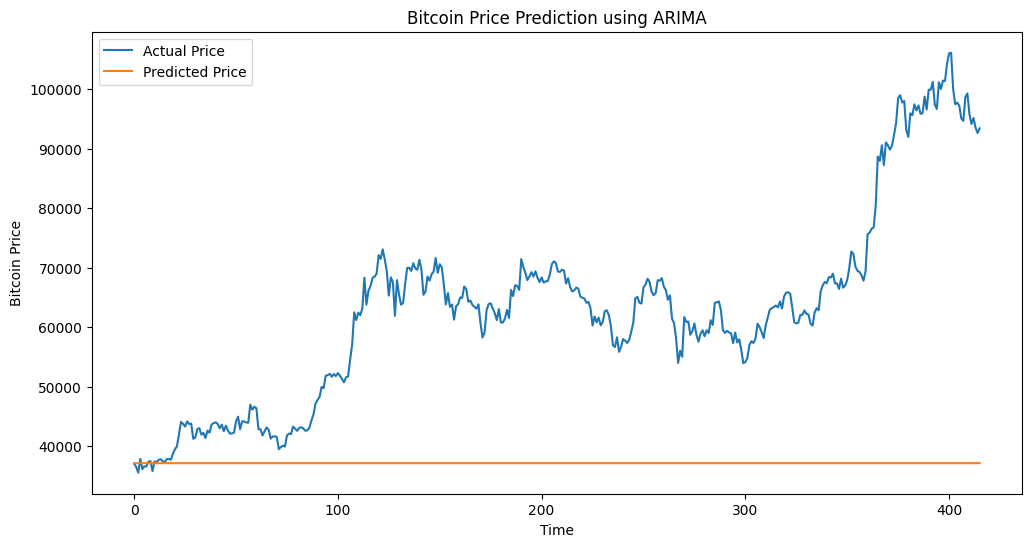

In [ ]:
# Plot hasil prediksi
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled_arim, label='Actual Price')
plt.plot(y_pred_rescaled_arim, label='Predicted Price')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bitcoin Price')
plt.title('Bitcoin Price Prediction using ARIMA')  # Tetap sesuai permintaan
plt.show()

In [ ]:
# Evaluasi model
mae = mean_absolute_error(y_test_rescaled_arim, y_pred_rescaled_arim)
rmse = np.sqrt(mean_squared_error(y_test_rescaled_arim, y_pred_rescaled_arim))
mape = np.mean(np.abs((y_test_rescaled_arim - y_pred_rescaled_arim) / y_test_rescaled_arim)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 25787.6545
Root Mean Squared Error (RMSE): 30370.4420
Mean Absolute Percentage Error (MAPE): 37.08%


In [ ]:
# Train residual
train_pred_scaled = model_fit1.predict(start=0, end=len(train_scaled)-1)
train_residuals = train_scaled.flatten() - train_pred_scaled

# Test residual
start = len(train_scaled)
end = start + len(test_scaled) - 1
test_pred_scaled = model_fit1.predict(start=start, end=end)
test_residuals = test_scaled.flatten() - test_pred_scaled

### Residual Plot

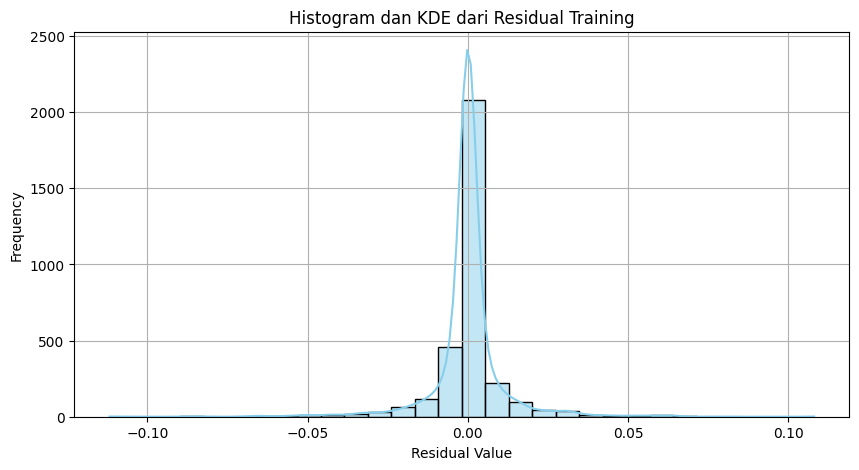

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(train_residuals, kde=True, bins=30, color='skyblue')
plt.title('Histogram dan KDE dari Residual Training')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


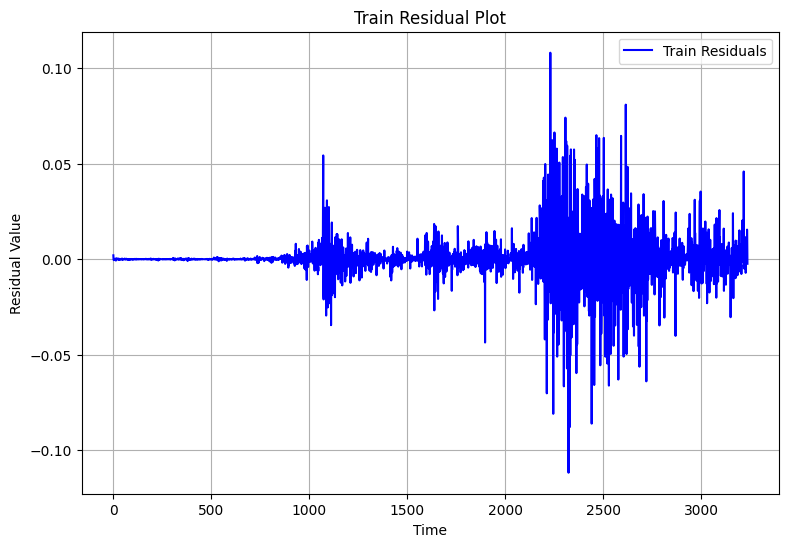

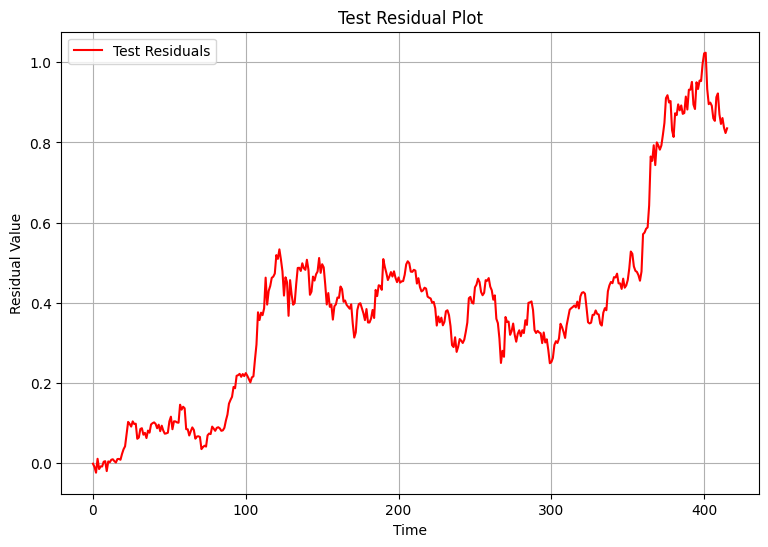

In [ ]:
# Plot residual dari data training
plt.figure(figsize=(9, 6))
plt.plot(train_residuals, label='Train Residuals', color='blue')
plt.title('Train Residual Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot residual dari data testing
plt.figure(figsize=(9, 6))
plt.plot(test_residuals, label='Test Residuals', color='red')
plt.title('Test Residual Plot')
plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Siapkan data untuk LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 50
X_train, y_train = create_sequences(train_residuals.reshape(-1, 1), seq_length)
X_test, y_test = create_sequences(test_residuals.reshape(-1, 1), seq_length)

In [ ]:
# Bangun dan latih LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - loss: 1.8363e-04 - val_loss: 0.2087
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 1.6109e-04 - val_loss: 0.2185
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - loss: 1.5639e-04 - val_loss: 0.2182
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 1.5476e-04 - val_loss: 0.2230
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 1.5355e-04 - val_loss: 0.2239
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - loss: 1.5273e-04 - val_loss: 0.2262
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 1.5250e-04 - val_loss: 0.2270
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - loss: 1.5253e-04 - val_loss: 0.2284
Epoch 9/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - loss: 1.5249e-04 - val_loss: 0.2296
Epoch 10/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 1.5234e-04 - val_loss: 0.2294


In [ ]:
# Prediksi residual menggunakan LSTM
residual_pred = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [ ]:
# Hybrid = ARIMA prediction + predicted residual
# Sinkronkan panjangnya dengan prediksi LSTM (karena terpotong oleh sequence)
arima_pred_short = test_pred_scaled[seq_length:]
arima_pred_rescaled = scaler.inverse_transform(arima_pred_short.reshape(-1, 1)).flatten()
residual_pred_rescaled = scaler.inverse_transform(
    np.concatenate((residual_pred, np.zeros((residual_pred.shape[0], 1))), axis=1)
)[:, 0]

# Final prediction
final_pred_1 = arima_pred_rescaled + residual_pred_rescaled

# Ground truth (disesuaikan panjangnya)
y_test_true = test_scaled[seq_length:]
y_test_rescaled = scaler.inverse_transform(y_test_true.reshape(-1, 1)).flatten()

### Visualisasi Hybrid

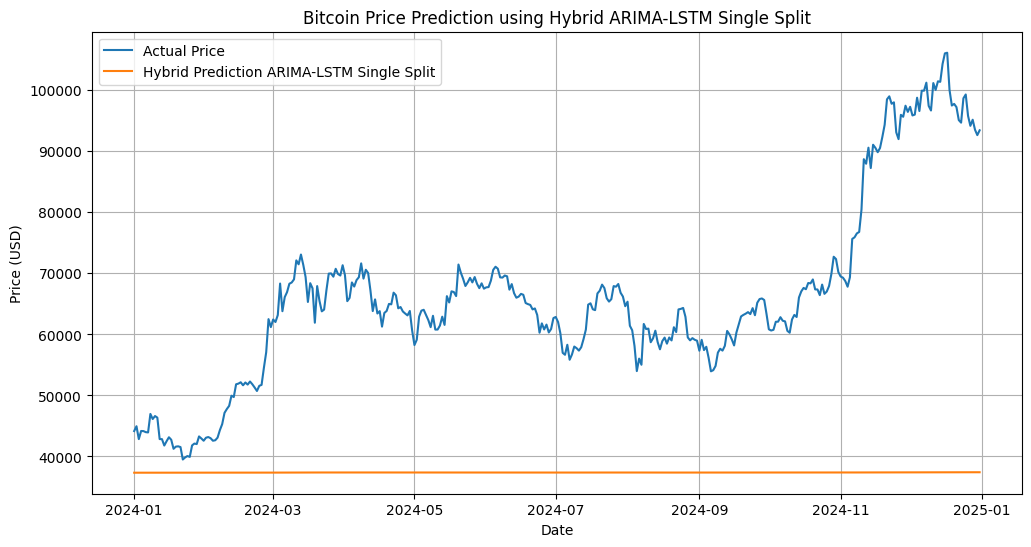

In [ ]:
test_index_3 = df.loc['2023-11-12':'2024-12-31'].index[seq_length:]

# Plot hasil prediksi
plt.figure(figsize=(12,6))
plt.plot(test_index_3, y_test_rescaled, label='Actual Price')
plt.plot(test_index_3, final_pred_1, label='Hybrid Prediction ARIMA-LSTM Single Split')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Bitcoin Price Prediction using Hybrid ARIMA-LSTM Single Split')
plt.grid(True)
plt.show()

In [ ]:
# Evaluasi
mae = mean_absolute_error(y_test_rescaled, final_pred_1)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, final_pred_1))
mape = np.mean(np.abs((y_test_rescaled - final_pred_1) / y_test_rescaled)) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 28587.1967
Root Mean Squared Error (RMSE): 32119.4158
Mean Absolute Percentage Error (MAPE): 40.63%


# perbandingan model tunggal

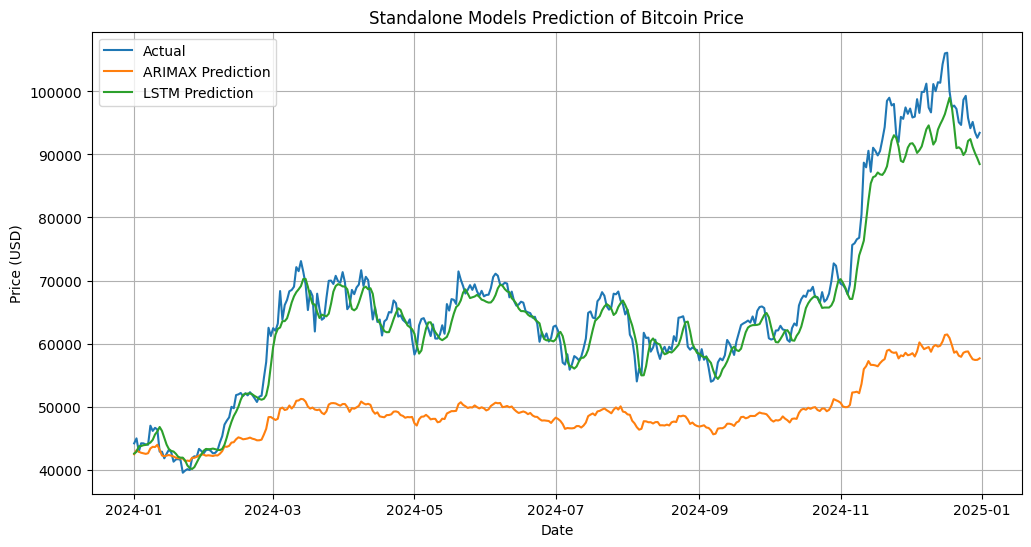

In [ ]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(true.index, true.values, label='Actual')
# plt.plot(true.index, pred_arim_trimmed, label='ARIMAX Prediction')
plt.plot(true.index, pred_arim, label='ARIMAX Prediction')
plt.plot(true.index, y_pred_rescaled, label='LSTM Prediction')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Standalone Models Prediction of Bitcoin Price')
plt.grid(True)
plt.show()

# Perbandingan model Hybrid

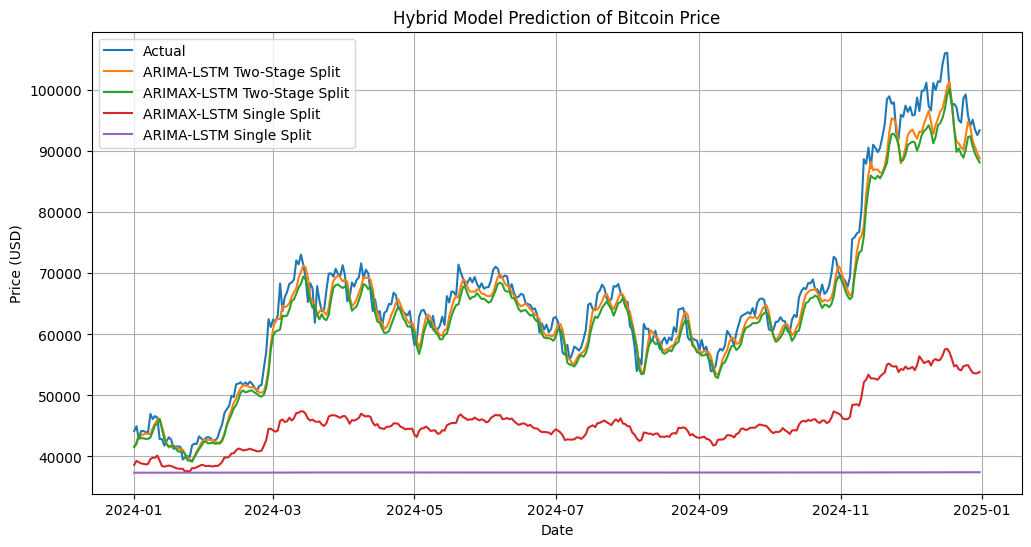

In [ ]:
# Plot
plt.figure(figsize=(12,6))
# plt.plot(testActual, label='Actual Price', color='blue')
plt.plot(true.index, true.values, label='Actual')
plt.plot(true.index, final_pred, label='ARIMA-LSTM Two-Stage Split')
plt.plot(true.index, final_hybrid_pred, label='ARIMAX-LSTM Two-Stage Split')

# Adjust the index to match the length of y_pred_hybrid
plt.plot(true.index, y_pred_hybrid, label='ARIMAX-LSTM Single Split') # Modified line
plt.plot(true.index, final_pred_1, label='ARIMA-LSTM Single Split') # Modified line

plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Hybrid Model Prediction of Bitcoin Price')
plt.grid(True)
plt.show()

# perbadingan model tunggal dan hybrid

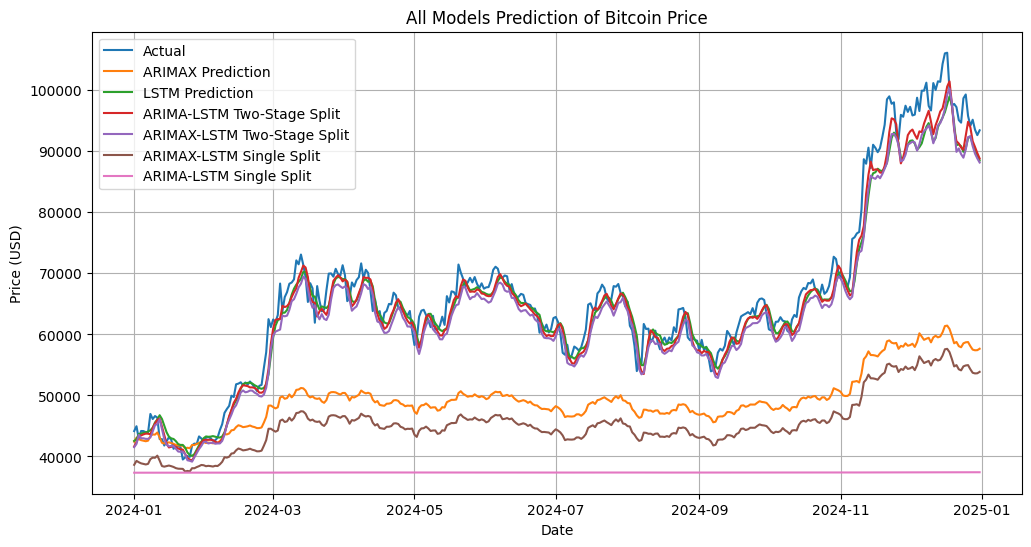

In [ ]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(true.index, true.values, label='Actual')
plt.plot(true.index, pred_arim, label='ARIMAX Prediction')
plt.plot(true.index, y_pred_rescaled, label='LSTM Prediction')
plt.plot(true.index, final_pred, label='ARIMA-LSTM Two-Stage Split')
plt.plot(true.index, final_hybrid_pred, label='ARIMAX-LSTM Two-Stage Split')
plt.plot(true.index, y_pred_hybrid, label='ARIMAX-LSTM Single Split')
plt.plot(true.index, final_pred_1, label='ARIMA-LSTM Single Split') # Modified line
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('All Models Prediction of Bitcoin Price')
plt.grid(True)
plt.show()

# perbandingan model hybrid single split

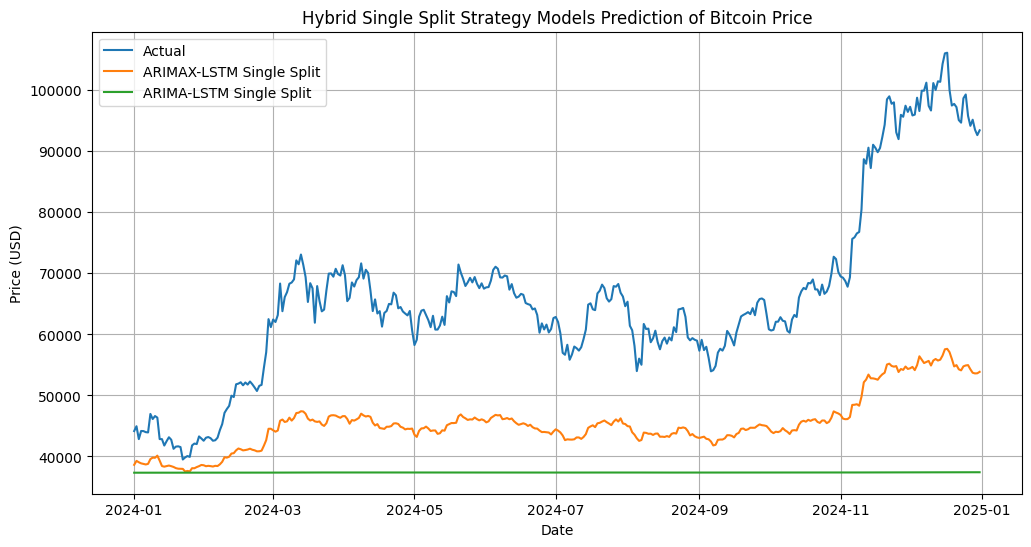

In [ ]:
# Plot
plt.figure(figsize=(12,6))
# plt.plot(testActual, label='Actual Price', color='blue')
plt.plot(true.index, true.values, label='Actual')

# Adjust the index to match the length of y_pred_hybrid
plt.plot(true.index, y_pred_hybrid, label='ARIMAX-LSTM Single Split') # Modified line
plt.plot(true.index, final_pred_1, label='ARIMA-LSTM Single Split') # Modified line

plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Hybrid Single Split Strategy Models Prediction of Bitcoin Price')
plt.grid(True)
plt.show()

# perbandingan model hybrid two stage split

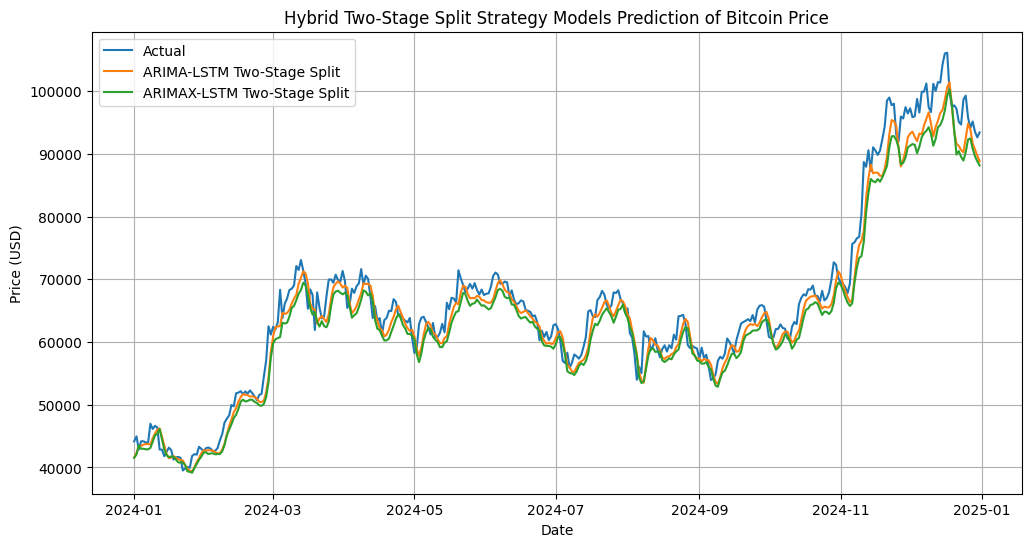

In [ ]:
# Plot
plt.figure(figsize=(12,6))
# plt.plot(testActual, label='Actual Price', color='blue')
plt.plot(true.index, true.values, label='Actual')
plt.plot(true.index, final_pred, label='ARIMA-LSTM Two-Stage Split')
plt.plot(true.index, final_hybrid_pred, label='ARIMAX-LSTM Two-Stage Split')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Hybrid Two-Stage Split Strategy Models Prediction of Bitcoin Price')
plt.grid(True)
plt.show()

# All Time Series

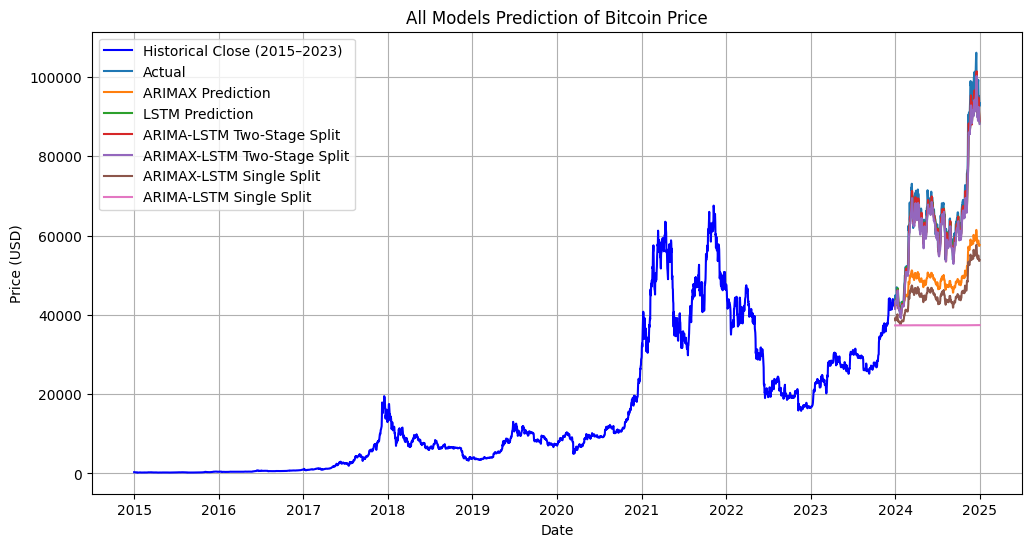

In [ ]:
# Plot
plt.figure(figsize=(12,6))

# Plot historis 2015–2023
plt.plot(df.loc['2015-01-01':'2023-12-31'].index,
         df.loc['2015-01-01':'2023-12-31']["Close"],
         label='Historical Close (2015–2023)',
         color='blue', linewidth=1.5)

plt.plot(true.index, true.values, label='Actual')
plt.plot(true.index, pred_arim, label='ARIMAX Prediction')
plt.plot(true.index, y_pred_rescaled, label='LSTM Prediction')
plt.plot(true.index, final_pred, label='ARIMA-LSTM Two-Stage Split')
plt.plot(true.index, final_hybrid_pred, label='ARIMAX-LSTM Two-Stage Split')
plt.plot(true.index, y_pred_hybrid, label='ARIMAX-LSTM Single Split')
plt.plot(true.index, final_pred_1, label='ARIMA-LSTM Single Split') # Modified line
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('All Models Prediction of Bitcoin Price')
plt.grid(True)
plt.show()

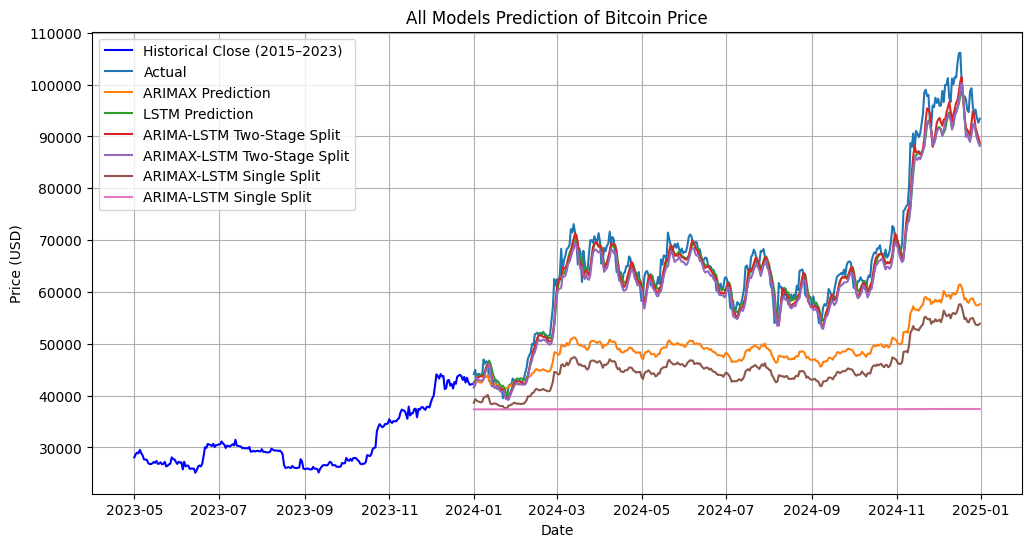

In [ ]:
# Plot
plt.figure(figsize=(12,6))

# Plot historis 2015–2023
plt.plot(df.loc['2023-05-01':'2023-12-31'].index,
         df.loc['2023-05-01':'2023-12-31']["Close"],
         label='Historical Close (2015–2023)',
         color='blue', linewidth=1.5)

plt.plot(true.index, true.values, label='Actual')
plt.plot(true.index, pred_arim, label='ARIMAX Prediction')
plt.plot(true.index, y_pred_rescaled, label='LSTM Prediction')
plt.plot(true.index, final_pred, label='ARIMA-LSTM Two-Stage Split')
plt.plot(true.index, final_hybrid_pred, label='ARIMAX-LSTM Two-Stage Split')
plt.plot(true.index, y_pred_hybrid, label='ARIMAX-LSTM Single Split')
plt.plot(true.index, final_pred_1, label='ARIMA-LSTM Single Split') # Modified line
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('All Models Prediction of Bitcoin Price')
plt.grid(True)
plt.show()